# Deep Generative Modeling for AI-Guided Inverse Design of Perovskite Photovoltaic Devices
**Revision run — reproduces the submitted pipeline (Part A, figs 02–19) and adds the reviewer-requested experiments (Part B, figs R01–R05).**

- Dataset: `balanced_50k.csv` (49,998 drift-diffusion simulations, 3 balanced recombination classes)
- Seed 42 everywhere. All preprocessing is fitted inside each CV fold (leakage-free). All plots are saved to `figures/` **and** shown.
- Runtime: ~40 min for Part A, ~45 min for Part B on a Kaggle T4 GPU. Turn **GPU ON** in notebook settings.

**Part A (original paper):** EDA → feature engineering → 5-fold surrogate CV → Wilcoxon/paired-t → SHAP + permutation importance + MI → FiLM-cVAE + classifier-free guidance → CFG sweep → hit-rate vs baselines → KS plausibility → result table.

**Part B (revision experiments):**
| Section | Reviewer comment | Experiment |
|---|---|---|
| 13 | R2.5, R3.2 | Per-class SHAP + per-class permutation importance (GB_tr discrepancy) |
| 14 | R2.8 | Guidance-scale w robustness across seeds/splits/targets |
| 15 | R2.10 | Latent-dim × width sensitivity grid |
| 16 | R3.5 | Validity / uniqueness / novelty of generated devices |
| 17 | R3.4, R2.1 | Representative candidates table + CSV export for SIMsalabim re-simulation |
| 18 | R2.4 | Effect sizes (practical significance) alongside p-values |

## Section 1 — Imports, seeding, figure helper

In [1]:
import os, re, glob, json, math, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
random.seed(SEED); np.random.seed(SEED)

import torch
import torch.nn as nn
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import sklearn
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors

try:
    from xgboost import XGBRegressor; HAS_XGB = True
except Exception:
    HAS_XGB = False
try:
    from lightgbm import LGBMRegressor; HAS_LGBM = True
except Exception:
    HAS_LGBM = False
import shap

FIGDIR = "/kaggle/working/figures" if os.path.isdir("/kaggle/working") else "./figures"
os.makedirs(FIGDIR, exist_ok=True)

def save_show(name):
    """Save the current figure under its manuscript filename, then display it."""
    plt.savefig(os.path.join(FIGDIR, name), dpi=200, bbox_inches="tight")
    plt.show()

print("torch", torch.__version__, "| sklearn", sklearn.__version__,
      "| shap", shap.__version__, "| xgb:", HAS_XGB, "| lgbm:", HAS_LGBM, "| device:", DEVICE)

torch 2.10.0+cu128 | sklearn 1.6.1 | shap 0.50.0 | xgb: True | lgbm: True | device: cuda


## Section 2 — Data loading, column detection, PCE proxy

In [2]:
DATA_PATH = "/kaggle/input/datasets/mirzayasirabdullah07/drp-for-perovskite-solar-cells-dataset/balanced_50k.csv"
if not os.path.exists(DATA_PATH):
    hits = (glob.glob("/kaggle/input/**/balanced_50k.csv", recursive=True)
            or glob.glob("./balanced_50k.csv") or glob.glob("../input/**/balanced_50k.csv", recursive=True))
    assert hits, "balanced_50k.csv not found — attach the dataset to the notebook."
    DATA_PATH = hits[0]
df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Missing values total:", int(df.isna().sum().sum()))
print("Duplicates:", int(df.duplicated().sum()))
print("Label distribution:\n", df["label"].value_counts())

# Device (input) columns = everything that is not a simulator output.
OUT_EXACT = {"n", "R2w", "aplhaw", "alphaw", "alphaR2w", "Gmax", "label"}
OUT_PREFIX = ("Voc", "Jsc", "FF", "PCE", "frac_rec")
DEVICE_COLS = [c for c in df.columns if c not in OUT_EXACT and not c.startswith(OUT_PREFIX)]
print(f"\n{len(DEVICE_COLS)} device parameters:", DEVICE_COLS)

def _sun_value(name):
    m = re.findall(r"(\d+(?:\.\d+)?)", name)
    return float(m[-1]) if m else None

def pick_1sun(prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    if len(cols) == 1:
        return cols[0]
    return max(cols, key=lambda c: _sun_value(c) if _sun_value(c) is not None else -1.0)

VOC, JSC, FFC = pick_1sun("Voc"), pick_1sun("Jsc"), pick_1sun("FF")
print("1-sun target columns:", VOC, "|", JSC, "|", FFC)

P_IN = 1000.0  # W m^-2 at 1 sun
df["PCE_proxy"] = df[VOC] * df[JSC].abs() * df[FFC] / P_IN
TARGETS4 = [VOC, JSC, FFC, "PCE_proxy"]
lab = df["label"].astype(int).values
print(df["PCE_proxy"].describe())

Loaded: /kaggle/input/datasets/mirzayasirabdullah07/drp-for-perovskite-solar-cells-dataset/balanced_50k.csv
Shape: (49998, 50)
Missing values total: 0
Duplicates: 0
Label distribution:
 label
0.0    16666
1.0    16666
2.0    16666
Name: count, dtype: int64

25 device parameters: ['L', 'LIL', 'LIR', 'mob_IL', 'mob_IR', 'mun_0', 'mup_0', 'phi_left', 'phi_right', 'IL_dop', 'IR_dop', 'Lang_pre', 'St_L', 'St_R', 'Etrap', 'Cn', 'Cp', 'GB_tr', 'num_GBs', 'doping_left', 'doping_right', 'Rseries', 'Rshunt', 'mobility_ratio', 'phi_mean']
1-sun target columns: Voc1.00 | Jsc1.00 | FF1.00
count    49998.000000
mean         0.186496
std          0.046884
min          0.041636
25%          0.151891
50%          0.191912
75%          0.225296
max          0.272696
Name: PCE_proxy, dtype: float64


## Section 3 — EDA (figs 02–05)

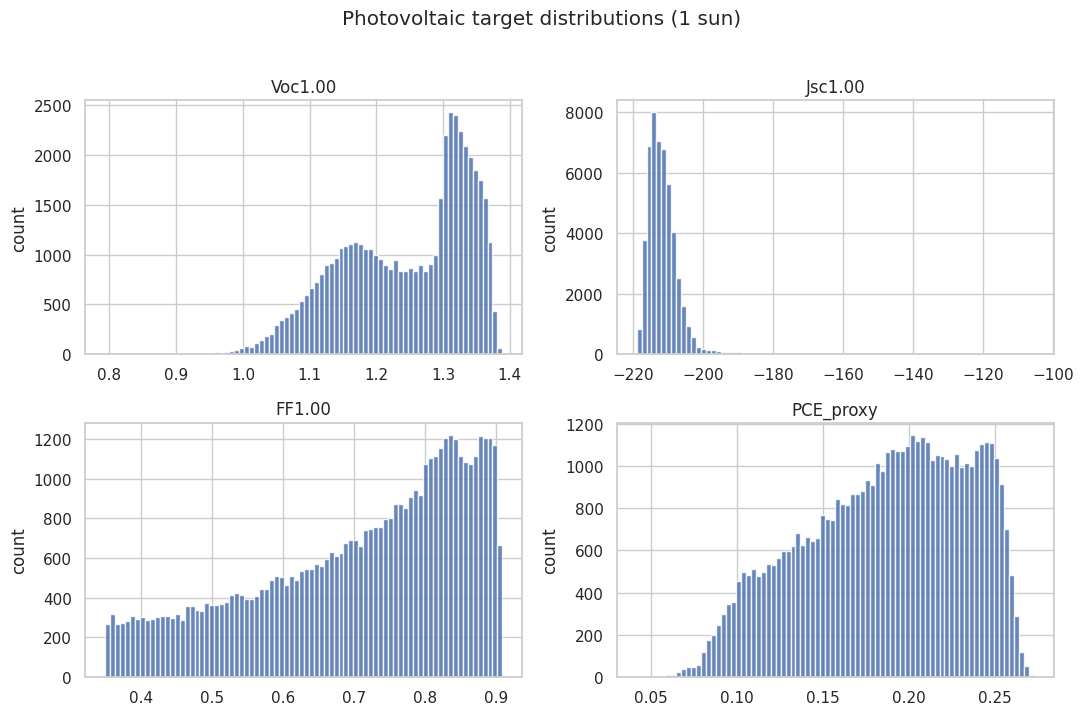

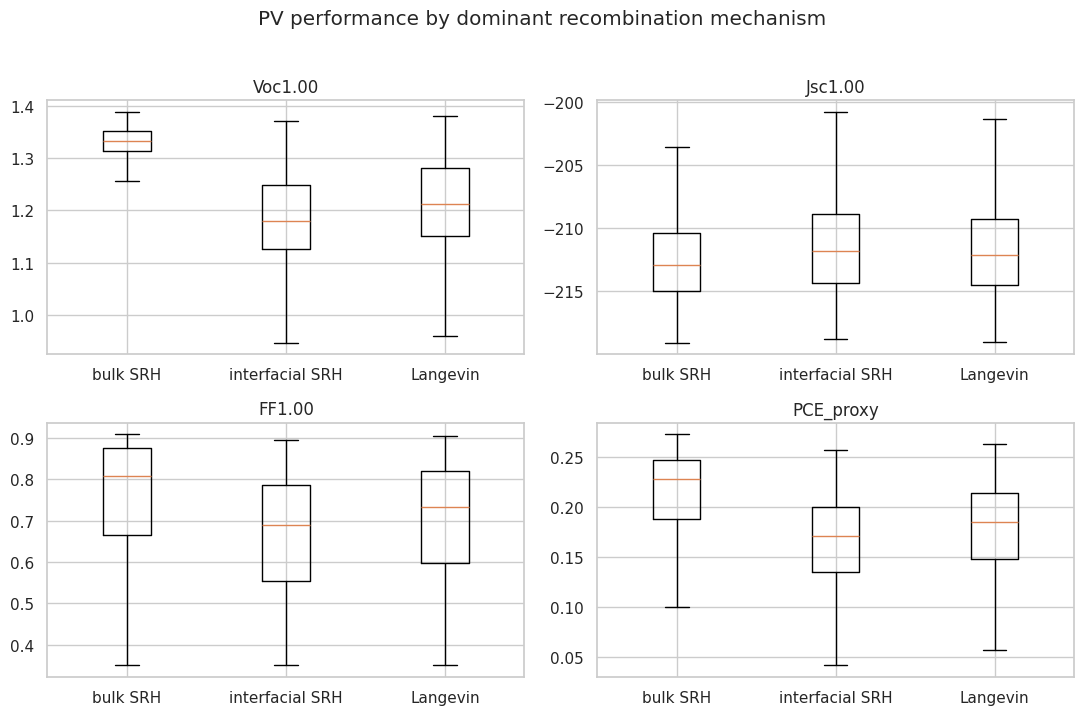

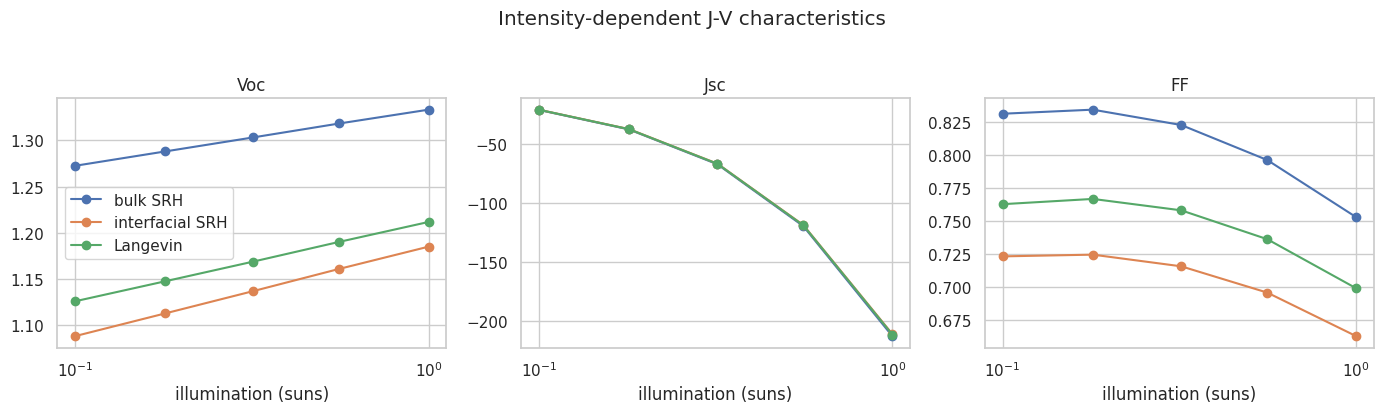

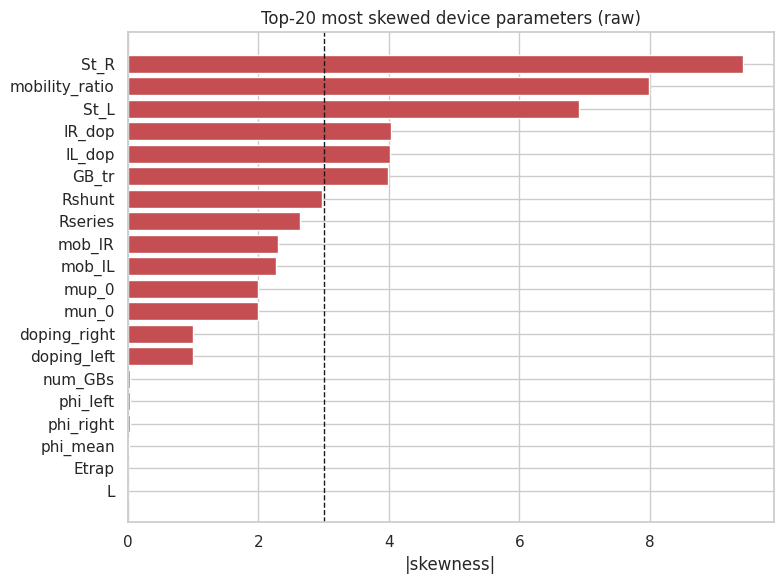

In [3]:
# fig02 — target distributions
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.ravel(), TARGETS4):
    ax.hist(df[c], bins=80, color="#4C72B0", alpha=0.85)
    ax.set_title(c); ax.set_ylabel("count")
fig.suptitle("Photovoltaic target distributions (1 sun)", y=1.02)
plt.tight_layout(); save_show("fig02_eda_target_distributions.png")

# fig03 — PV performance by recombination class
CLASS_NAMES = {0: "bulk SRH", 1: "interfacial SRH", 2: "Langevin"}
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.ravel(), TARGETS4):
    data = [df.loc[lab == k, c] for k in sorted(np.unique(lab))]
    ax.boxplot(data, showfliers=False)
    ax.set_xticklabels([CLASS_NAMES.get(k, k) for k in sorted(np.unique(lab))])
    ax.set_title(c)
fig.suptitle("PV performance by dominant recombination mechanism", y=1.02)
plt.tight_layout(); save_show("fig03_eda_pv_by_class.png")

# fig04 — intensity dependence
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, pref in zip(axes, ["Voc", "Jsc", "FF"]):
    cols = sorted([c for c in df.columns if c.startswith(pref)], key=lambda c: _sun_value(c) or 0)
    suns = [_sun_value(c) for c in cols]
    for k in sorted(np.unique(lab)):
        ax.plot(suns, [df.loc[lab == k, c].mean() for c in cols], "o-", label=CLASS_NAMES.get(k, k))
    ax.set_xlabel("illumination (suns)"); ax.set_title(pref); ax.set_xscale("log")
axes[0].legend()
fig.suptitle("Intensity-dependent J-V characteristics", y=1.03)
plt.tight_layout(); save_show("fig04_eda_intensity_dependence.png")

# fig05 — skewness of raw device parameters
sk = df[DEVICE_COLS].skew().abs().sort_values(ascending=False).head(20)
plt.figure(figsize=(8, 6))
plt.barh(sk.index[::-1], sk.values[::-1], color="#C44E52")
plt.axvline(3, ls="--", c="k", lw=1); plt.xlabel("|skewness|")
plt.title("Top-20 most skewed device parameters (raw)")
plt.tight_layout(); save_show("fig05_eda_feature_skewness.png")

## Section 4 — Feature engineering: signed-log, 9 physics composites, redundancy filter (fig 06)

Features with |skew| > 3 (signed-log10 transform):
{'St_R': 9.430717077960432, 'St_L': 6.916575348873819, 'mobility_ratio': 6.161870421980087, 'bulk_trap_intensity': 4.769400627979356, 'IR_dop': 4.031368663021797, 'IL_dop': 4.023394466717836, 'GB_tr': 3.9786945304285415}
redundancy: |r(GB_tr,bulk_trap_intensity)| = 0.995 -> drop bulk_trap_intensity

Final feature dimensionality d = 32


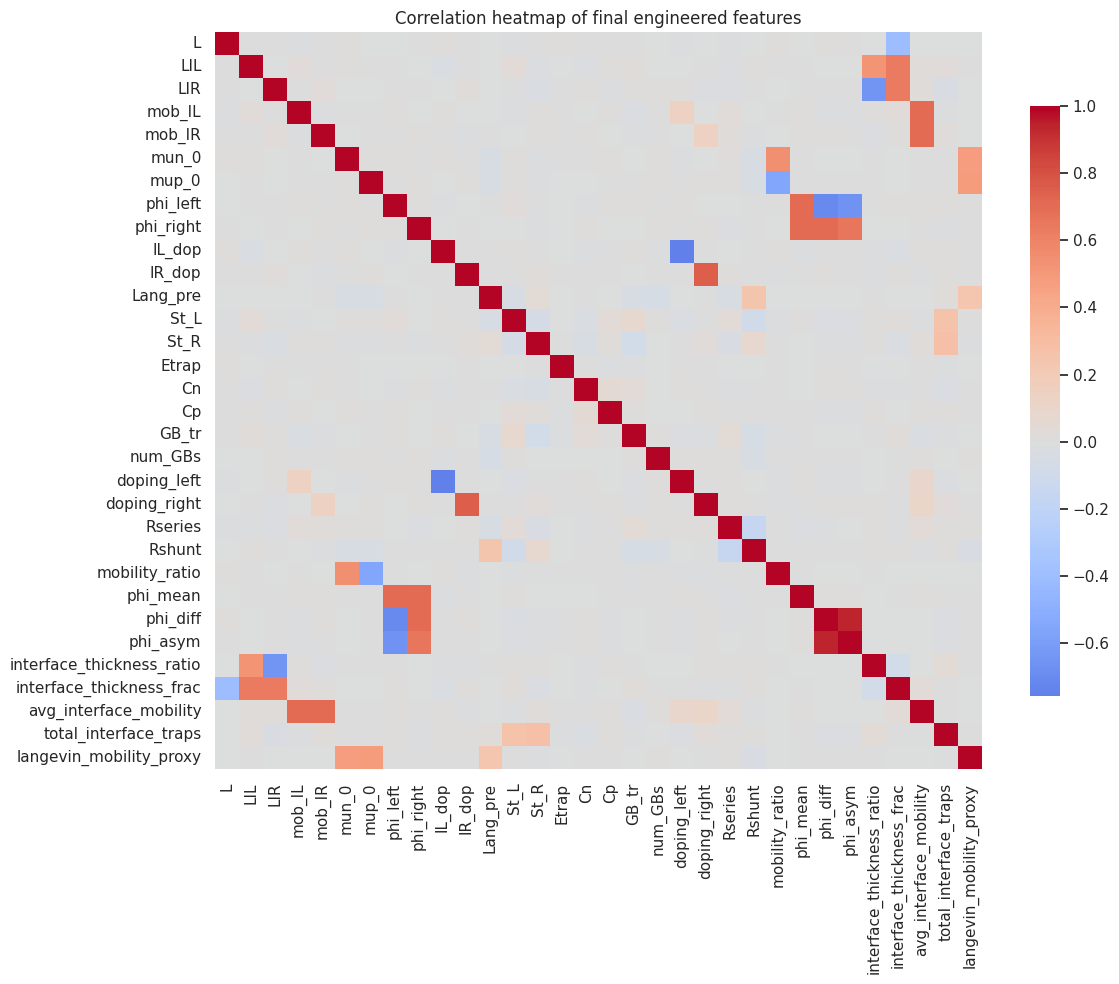

In [4]:
work = df[DEVICE_COLS].copy()
EPS = 1e-30

# Nine physics-informed composite descriptors
work["phi_diff"] = work["phi_right"] - work["phi_left"]
work["phi_asym"] = work["phi_diff"] / (work["phi_left"].abs() + work["phi_right"].abs() + EPS)
work["interface_thickness_ratio"] = work["LIL"] / (work["LIR"] + EPS)
work["interface_thickness_frac"] = (work["LIL"] + work["LIR"]) / (work["L"] + EPS)
work["mobility_ratio"] = work["mun_0"] / (work["mup_0"] + EPS)
work["avg_interface_mobility"] = (work["mob_IL"] + work["mob_IR"]) / 2.0
work["total_interface_traps"] = work["St_L"] + work["St_R"]
work["bulk_trap_intensity"] = work["GB_tr"] * work["num_GBs"]
work["langevin_mobility_proxy"] = work["Lang_pre"] * (work["mun_0"] + work["mup_0"])
ENGINEERED = ["phi_diff", "phi_asym", "interface_thickness_ratio", "interface_thickness_frac",
              "mobility_ratio", "avg_interface_mobility", "total_interface_traps",
              "bulk_trap_intensity", "langevin_mobility_proxy"]

# Signed-log10 transform for |skew| > 3
skew = work.skew()
SKEWED = skew[skew.abs() > 3].abs().sort_values(ascending=False)
print("Features with |skew| > 3 (signed-log10 transform):")
print(SKEWED.to_dict())
SKEWED = SKEWED.index.tolist()
# Record positivity BEFORE transforming: signed-log10 is only invertible for one-signed data
SKEWED_POSITIVE = {c: bool((work[c] > 0).all()) for c in SKEWED}
for c in SKEWED:
    work[c] = np.sign(work[c]) * np.log10(work[c].abs() + EPS)

# Pearson redundancy filter |r| > 0.97 (drop the engineered duplicate)
corr = work.corr().abs()
DROPPED = []
cols = list(work.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        if a in DROPPED or b in DROPPED:
            continue
        if corr.loc[a, b] > 0.97:
            victim = b if b in ENGINEERED else a
            DROPPED.append(victim)
            print(f"redundancy: |r({a},{b})| = {corr.loc[a, b]:.3f} -> drop {victim}")
FEATURES = [c for c in work.columns if c not in DROPPED]
X_all = work[FEATURES].astype(np.float64)
y_all = df["PCE_proxy"].values
C_raw = df[TARGETS4].values
print(f"\nFinal feature dimensionality d = {len(FEATURES)}")

# fig06 — correlation heatmap of final engineered feature set
plt.figure(figsize=(12, 10))
sns.heatmap(X_all.corr(), cmap="coolwarm", center=0, cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap of final engineered features")
plt.tight_layout(); save_show("fig06_correlation_heatmap.png")

## Section 5 — Mutual-information feature ranking (fig 07)

Rseries                     0.176877
GB_tr                       0.155315
total_interface_traps       0.088490
St_R                        0.051695
St_L                        0.044162
mob_IR                      0.036528
avg_interface_mobility      0.034309
mob_IL                      0.024228
doping_right                0.012462
interface_thickness_frac    0.012458
LIL                         0.011942
doping_left                 0.011697
LIR                         0.010909
IL_dop                      0.008255
num_GBs                     0.008055
dtype: float64


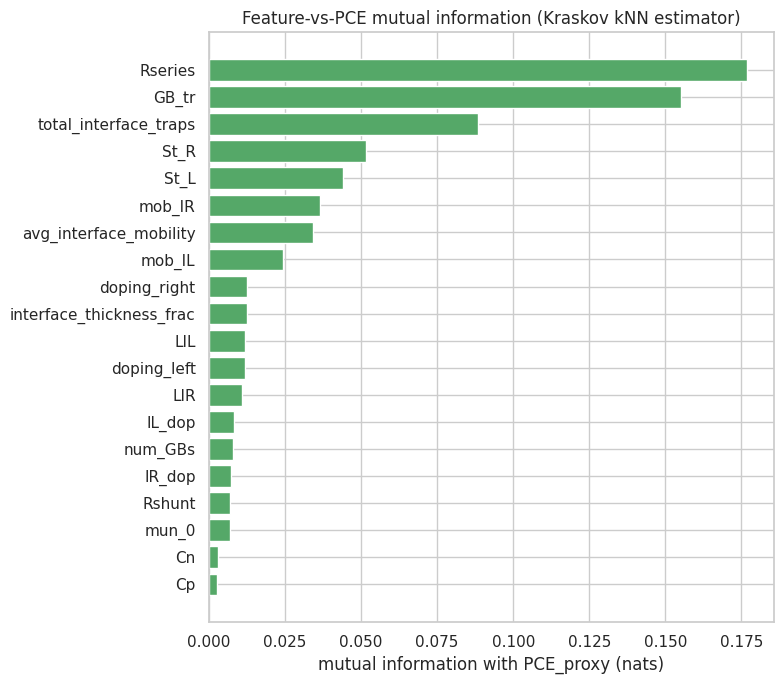

In [5]:
rng = np.random.RandomState(SEED)
sub = rng.choice(len(X_all), size=min(20000, len(X_all)), replace=False)
mi = mutual_info_regression(X_all.iloc[sub], y_all[sub], random_state=SEED)
MI_RANK = pd.Series(mi, index=FEATURES).sort_values(ascending=False)
print(MI_RANK.head(15))
plt.figure(figsize=(8, 7))
top = MI_RANK.head(20)
plt.barh(top.index[::-1], top.values[::-1], color="#55A868")
plt.xlabel("mutual information with PCE_proxy (nats)")
plt.title("Feature-vs-PCE mutual information (Kraskov kNN estimator)")
plt.tight_layout(); save_show("fig07_mutual_information_pce.png")

## Section 6 — Forward surrogate ensemble: leakage-free 5-fold stratified CV (figs 08–10)

fold 1/5 done (489s)
fold 2/5 done (984s)
fold 3/5 done (1468s)
fold 4/5 done (1973s)
fold 5/5 done (2471s)

5-fold CV results (out-of-fold):
       R2_mean   R2_std  RMSE_mean  MAE_mean
XGB    0.86613  0.00200    0.01715   0.01274
LGBM   0.86607  0.00209    0.01716   0.01274
GBR    0.85160  0.00234    0.01806   0.01349
RF     0.83007  0.00217    0.01933   0.01438
ET     0.82366  0.00119    0.01969   0.01471
MLP    0.71776  0.01339    0.02490   0.01887
Ridge  0.46071  0.00393    0.03443   0.02764

Best surrogate: XGB | oracle ensemble (top-3): ['XGB', 'LGBM', 'GBR'] | best tree (for SHAP): XGB


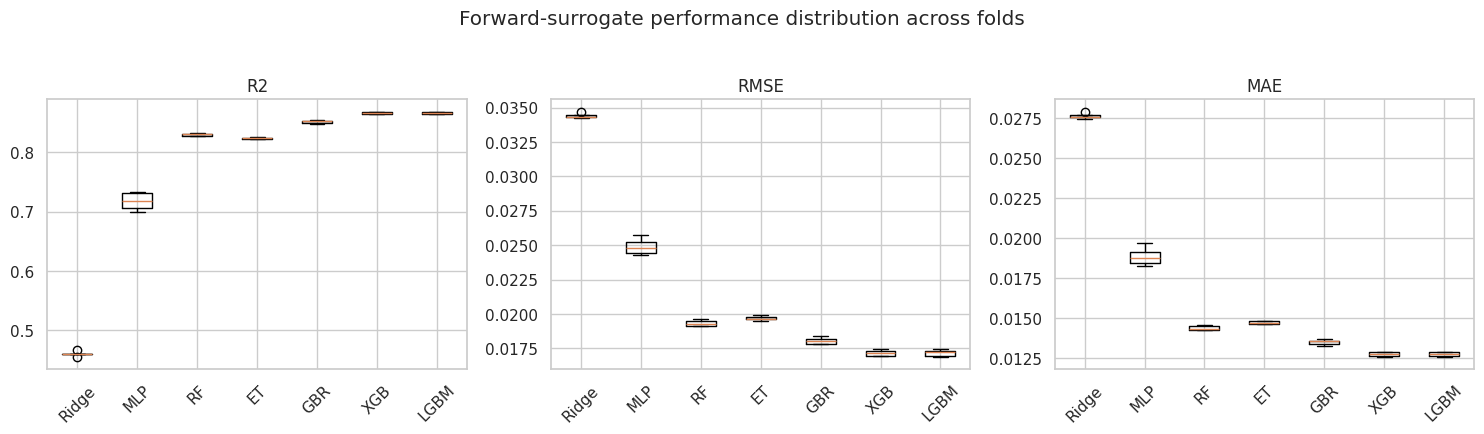

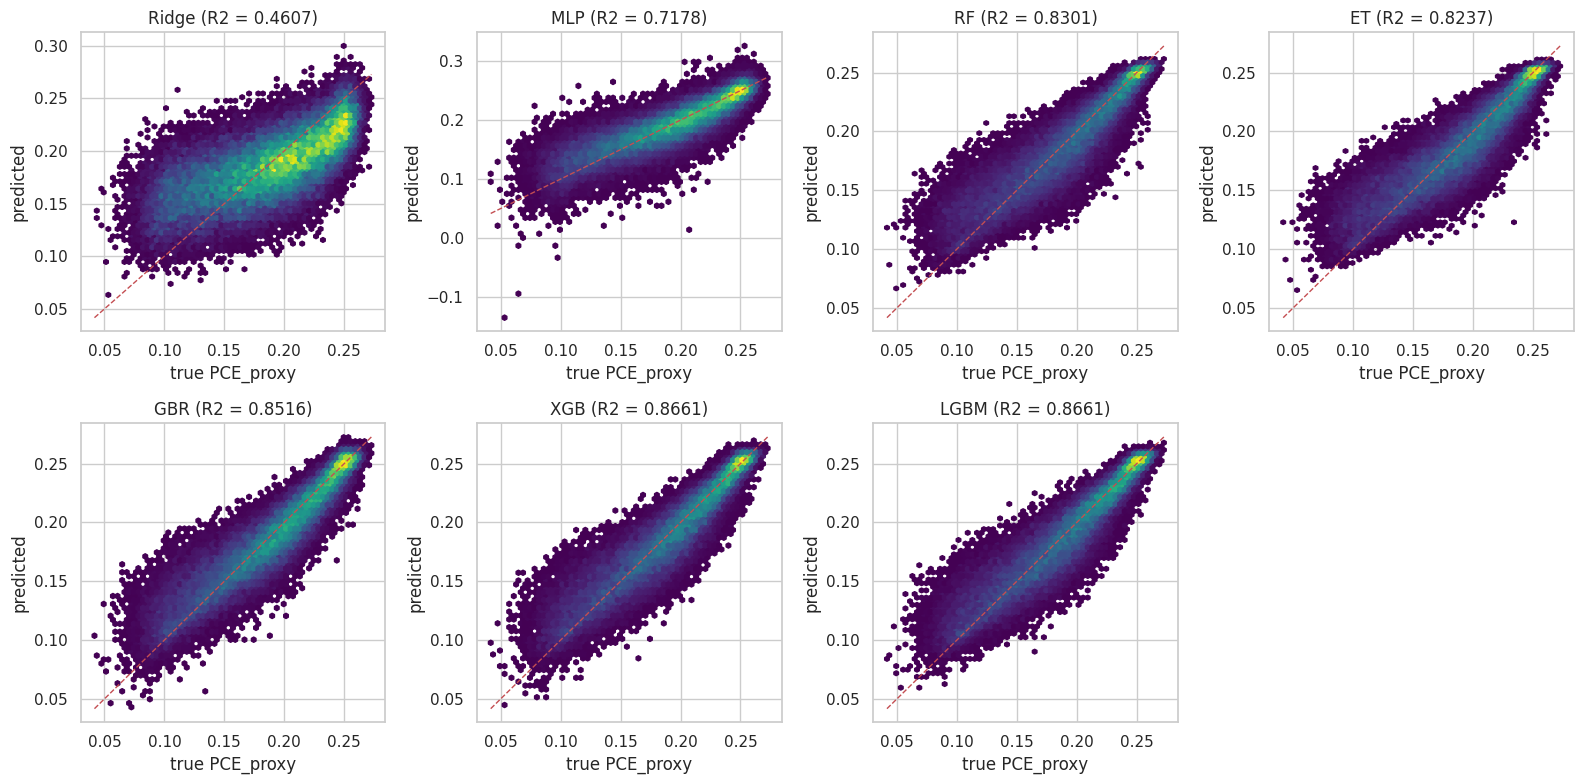

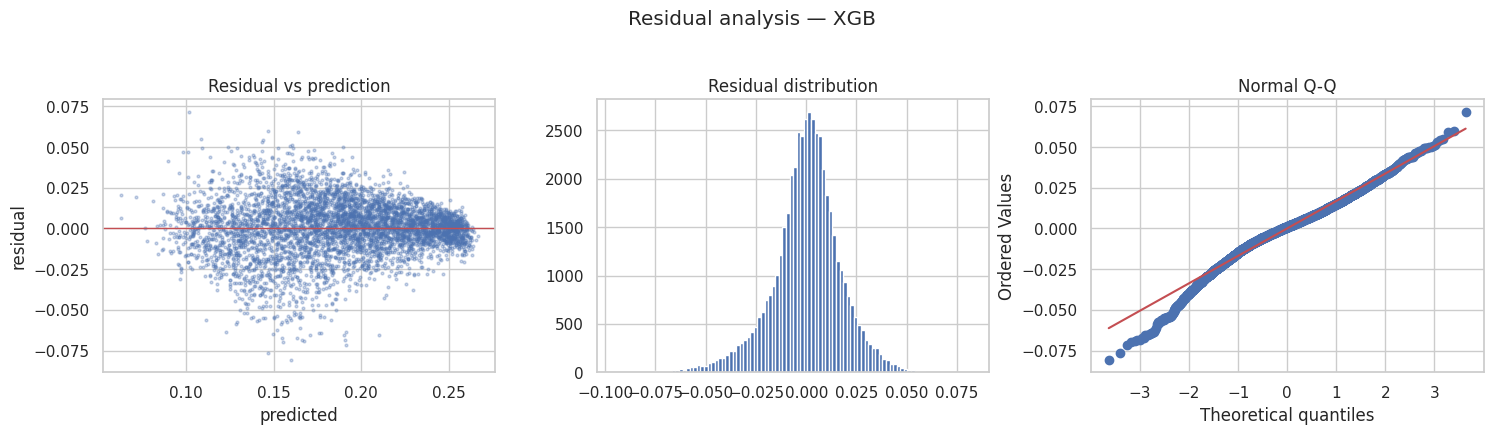

In [6]:
def make_models():
    m = {
        "Ridge": Ridge(alpha=1.0, random_state=SEED),
        "MLP": MLPRegressor(hidden_layer_sizes=(256, 256), activation="relu", batch_size=512,
                            learning_rate_init=1e-3, max_iter=200, early_stopping=True,
                            n_iter_no_change=10, random_state=SEED),
        "RF": RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=SEED),
        "ET": ExtraTreesRegressor(n_estimators=300, n_jobs=-1, random_state=SEED),
        "GBR": GradientBoostingRegressor(n_estimators=400, learning_rate=0.05, max_depth=4,
                                         random_state=SEED),
    }
    if HAS_XGB:
        m["XGB"] = XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.9,
                                colsample_bytree=0.9, tree_method="hist", n_jobs=-1,
                                random_state=SEED, verbosity=0)
    if HAS_LGBM:
        m["LGBM"] = LGBMRegressor(n_estimators=600, learning_rate=0.05, num_leaves=63,
                                  subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                                  random_state=SEED, verbose=-1)
    return m

MODEL_NAMES = list(make_models().keys())
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof = {name: np.zeros(len(X_all)) for name in MODEL_NAMES}
fold_metrics = defaultdict(lambda: defaultdict(list))  # metric -> model -> [per-fold]

t0 = time.time()
for fold, (tr, va) in enumerate(skf.split(X_all, lab), 1):
    # Leakage control: quantile transformer fitted on the training fold only
    qt = QuantileTransformer(n_quantiles=1000, output_distribution="normal",
                             subsample=200000, random_state=SEED).fit(X_all.iloc[tr])
    Xtr = qt.transform(X_all.iloc[tr]); Xva = qt.transform(X_all.iloc[va])
    for name, model in make_models().items():
        model.fit(Xtr, y_all[tr])
        p = model.predict(Xva)
        oof[name][va] = p
        fold_metrics["R2"][name].append(r2_score(y_all[va], p))
        fold_metrics["RMSE"][name].append(math.sqrt(mean_squared_error(y_all[va], p)))
        fold_metrics["MAE"][name].append(mean_absolute_error(y_all[va], p))
    print(f"fold {fold}/5 done ({time.time() - t0:.0f}s)")

cv_table = pd.DataFrame({
    "R2_mean": {m: np.mean(v) for m, v in fold_metrics["R2"].items()},
    "R2_std": {m: np.std(v) for m, v in fold_metrics["R2"].items()},
    "RMSE_mean": {m: np.mean(v) for m, v in fold_metrics["RMSE"].items()},
    "MAE_mean": {m: np.mean(v) for m, v in fold_metrics["MAE"].items()},
}).sort_values("R2_mean", ascending=False)
print("\n5-fold CV results (out-of-fold):")
print(cv_table.round(5))

BEST = cv_table.index[0]
TOP3 = list(cv_table.index[:3])
TREE_MODELS = [m for m in ["XGB", "LGBM", "RF", "ET", "GBR"] if m in cv_table.index]
BEST_TREE = max(TREE_MODELS, key=lambda m: cv_table.loc[m, "R2_mean"])
print(f"\nBest surrogate: {BEST} | oracle ensemble (top-3): {TOP3} | best tree (for SHAP): {BEST_TREE}")

# fig08 — CV metric distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, met in zip(axes, ["R2", "RMSE", "MAE"]):
    ax.boxplot([fold_metrics[met][m] for m in MODEL_NAMES])
    ax.set_xticklabels(MODEL_NAMES)
    ax.set_title(met); ax.tick_params(axis="x", rotation=45)
fig.suptitle("Forward-surrogate performance distribution across folds", y=1.03)
plt.tight_layout(); save_show("fig08_cv_metric_distributions.png")

# fig09 — out-of-fold parity plots
ncols = 4; nrows = int(np.ceil(len(MODEL_NAMES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
for ax, name in zip(np.ravel(axes), MODEL_NAMES):
    ax.hexbin(y_all, oof[name], gridsize=60, cmap="viridis", mincnt=1)
    lims = [y_all.min(), y_all.max()]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_title(f"{name} (R2 = {cv_table.loc[name, 'R2_mean']:.4f})")
    ax.set_xlabel("true PCE_proxy"); ax.set_ylabel("predicted")
for ax in np.ravel(axes)[len(MODEL_NAMES):]:
    ax.axis("off")
plt.tight_layout(); save_show("fig09_parity_plots.png")

# fig10 — residual analysis for the best model
res = y_all - oof[BEST]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
idx = rng.choice(len(res), 5000, replace=False)
axes[0].scatter(oof[BEST][idx], res[idx], s=4, alpha=0.3)
axes[0].axhline(0, c="r", lw=1); axes[0].set_xlabel("predicted"); axes[0].set_ylabel("residual")
axes[0].set_title("Residual vs prediction")
axes[1].hist(res, bins=100, color="#4C72B0"); axes[1].set_title("Residual distribution")
stats.probplot(res[idx], dist="norm", plot=axes[2]); axes[2].set_title("Normal Q-Q")
fig.suptitle(f"Residual analysis — {BEST}", y=1.03)
plt.tight_layout(); save_show("fig10_residual_analysis_best.png")

## Section 7 — Statistical comparison: Wilcoxon signed-rank + paired t + Shapiro (fig 11)

  comparison      dMAE    wilcoxon_p    paired_t_p    shapiro_p  significant
XGB vs Ridge -0.014896  0.000000e+00  0.000000e+00 1.267759e-23         True
  XGB vs MLP -0.006131  0.000000e+00  0.000000e+00 1.371248e-31         True
   XGB vs RF -0.001635  0.000000e+00  0.000000e+00 3.100683e-30         True
   XGB vs ET -0.001971  0.000000e+00  0.000000e+00 1.062140e-30         True
  XGB vs GBR -0.000747 8.011159e-193 1.492949e-185 4.073315e-25         True
 XGB vs LGBM  0.000002  5.054984e-01  9.242012e-01 1.038469e-33        False


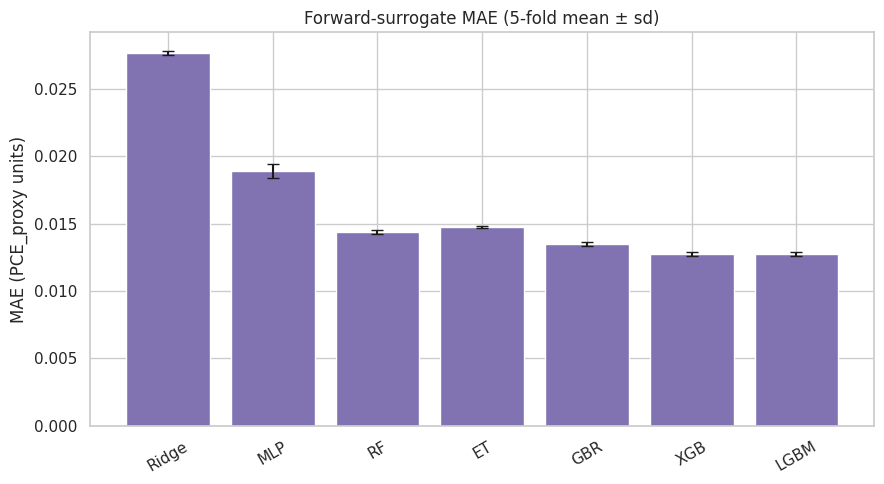

In [7]:
abs_err = {m: np.abs(y_all - oof[m]) for m in MODEL_NAMES}
rows = []
for other in [m for m in MODEL_NAMES if m != BEST]:
    diff = abs_err[BEST] - abs_err[other]
    w_stat, w_p = stats.wilcoxon(abs_err[BEST], abs_err[other])
    t_stat, t_p = stats.ttest_rel(abs_err[BEST], abs_err[other])
    sh_stat, sh_p = stats.shapiro(rng.choice(diff, 5000, replace=False))
    rows.append({"comparison": f"{BEST} vs {other}",
                 "dMAE": diff.mean(),
                 "wilcoxon_p": w_p, "paired_t_p": t_p, "shapiro_p": sh_p,
                 "significant": (w_p < 0.05) and (t_p < 0.05)})
stat_table = pd.DataFrame(rows)
print(stat_table.to_string(index=False))

# fig11 — MAE per model
plt.figure(figsize=(9, 5))
means = [np.mean(fold_metrics["MAE"][m]) for m in MODEL_NAMES]
stds = [np.std(fold_metrics["MAE"][m]) for m in MODEL_NAMES]
plt.bar(MODEL_NAMES, means, yerr=stds, capsize=4, color="#8172B2")
plt.ylabel("MAE (PCE_proxy units)"); plt.title("Forward-surrogate MAE (5-fold mean ± sd)")
plt.xticks(rotation=30)
plt.tight_layout(); save_show("fig11_mae_per_model_bars.png")

## Section 8 — Explainable AI: SHAP + permutation importance (figs 12–14) and oracle ensemble

oracle member XGB: val R2 = 0.8626
oracle member LGBM: val R2 = 0.8636
oracle member GBR: val R2 = 0.8466

SHAP mean|phi| top-10:
 GB_tr                       0.018070
Rseries                     0.016316
mob_IR                      0.009030
mob_IL                      0.008854
St_R                        0.007998
interface_thickness_frac    0.007597
St_L                        0.005931
IL_dop                      0.004266
avg_interface_mobility      0.003990
IR_dop                      0.003801
dtype: float32


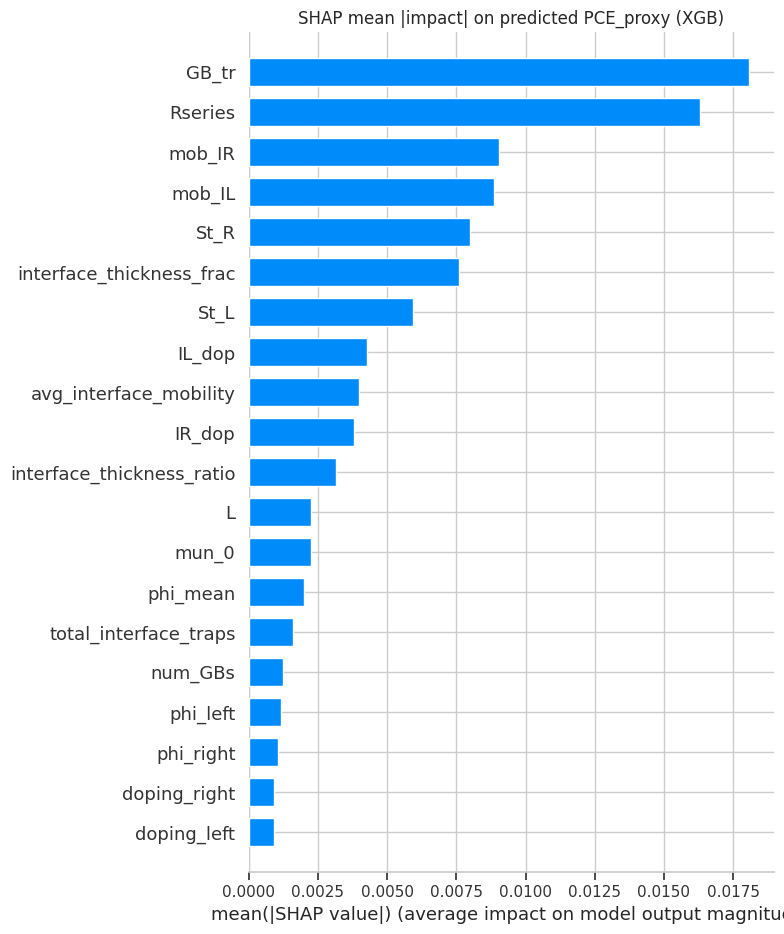

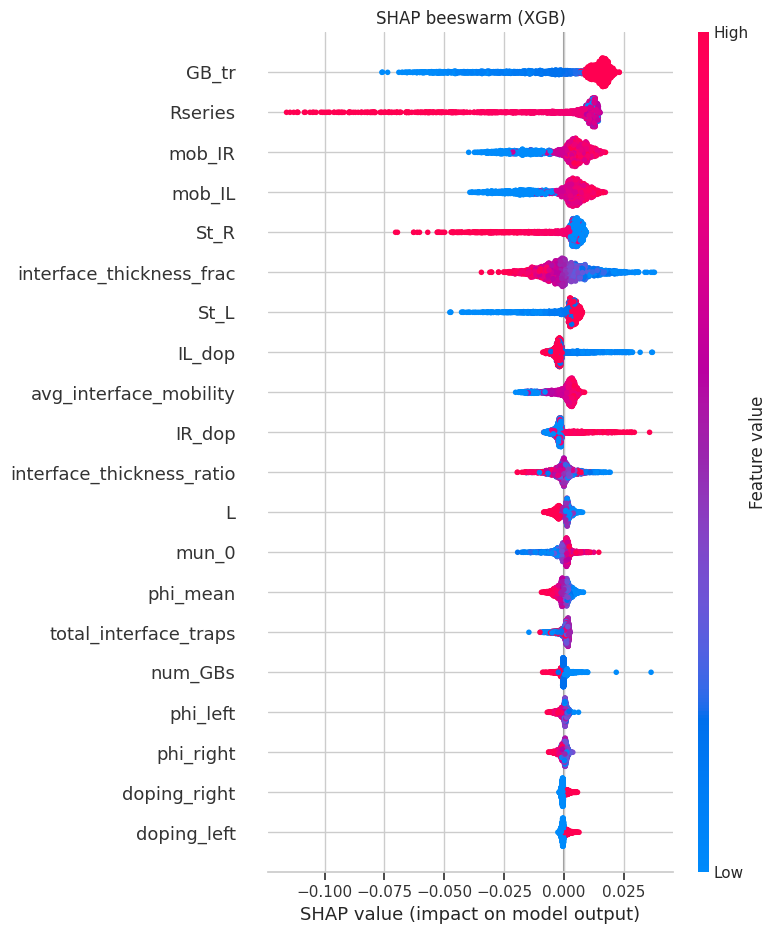


Permutation importance top-10:
 Rseries                      0.556839
GB_tr                        0.534954
mob_IR                       0.208800
mob_IL                       0.196103
St_R                         0.181596
interface_thickness_frac     0.159270
St_L                         0.116663
interface_thickness_ratio    0.090702
IR_dop                       0.069169
IL_dop                       0.065235
dtype: float64


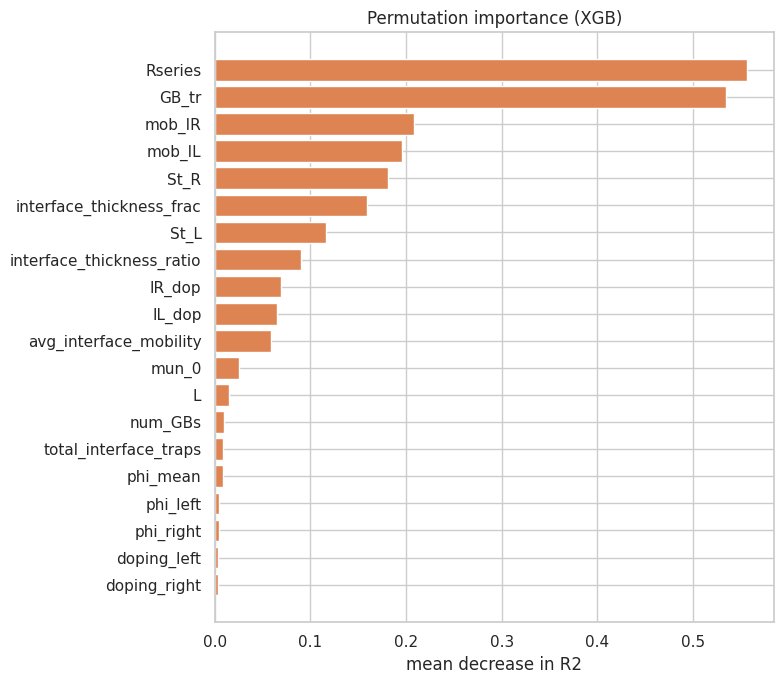

In [8]:
# Fixed 80/20 stratified split used for XAI, cVAE training, and the oracle
tr_idx, va_idx = train_test_split(np.arange(len(X_all)), test_size=0.2, stratify=lab, random_state=SEED)
QT = QuantileTransformer(n_quantiles=1000, output_distribution="normal",
                         subsample=200000, random_state=SEED).fit(X_all.iloc[tr_idx])
Xtr_q = pd.DataFrame(QT.transform(X_all.iloc[tr_idx]), columns=FEATURES)
Xva_q = pd.DataFrame(QT.transform(X_all.iloc[va_idx]), columns=FEATURES)
ytr, yva = y_all[tr_idx], y_all[va_idx]
lab_tr, lab_va = lab[tr_idx], lab[va_idx]

CSC = StandardScaler().fit(C_raw[tr_idx])
Ctr_s = CSC.transform(C_raw[tr_idx]); Cva_s = CSC.transform(C_raw[va_idx])

# Oracle ensemble: top-3 CV models refit on the 80% training split
ORACLE = {}
for name in TOP3:
    mdl = make_models()[name]
    mdl.fit(Xtr_q, ytr)
    ORACLE[name] = mdl
    print(f"oracle member {name}: val R2 = {r2_score(yva, mdl.predict(Xva_q)):.4f}")

def oracle_pce(X):
    X = pd.DataFrame(X, columns=FEATURES)
    return np.mean([m.predict(X) for m in ORACLE.values()], axis=0)

# SHAP on the best tree model
tree_model = ORACLE[BEST_TREE] if BEST_TREE in ORACLE else make_models()[BEST_TREE].fit(Xtr_q, ytr)
explainer = shap.TreeExplainer(tree_model)
shap_sample = Xva_q.sample(2000, random_state=SEED)
sv = explainer.shap_values(shap_sample)
SHAP_RANK = pd.Series(np.abs(sv).mean(0), index=FEATURES).sort_values(ascending=False)
print("\nSHAP mean|phi| top-10:\n", SHAP_RANK.head(10))

plt.figure()
shap.summary_plot(sv, shap_sample, plot_type="bar", max_display=20, show=False)
plt.title(f"SHAP mean |impact| on predicted PCE_proxy ({BEST_TREE})")
plt.tight_layout(); save_show("fig12_shap_summary_bar.png")

plt.figure()
shap.summary_plot(sv, shap_sample, max_display=20, show=False)
plt.title(f"SHAP beeswarm ({BEST_TREE})")
plt.tight_layout(); save_show("fig13_shap_beeswarm.png")

# Permutation importance on the best overall model
best_model = ORACLE[BEST] if BEST in ORACLE else make_models()[BEST].fit(Xtr_q, ytr)
pi_idx = np.arange(len(Xva_q))[:5000]
pi = permutation_importance(best_model, Xva_q.iloc[pi_idx], yva[pi_idx],
                            n_repeats=5, random_state=SEED, n_jobs=-1)
PERM_RANK = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False)
print("\nPermutation importance top-10:\n", PERM_RANK.head(10))

plt.figure(figsize=(8, 7))
top = PERM_RANK.head(20)
plt.barh(top.index[::-1], top.values[::-1], color="#DD8452")
plt.xlabel("mean decrease in R2"); plt.title(f"Permutation importance ({BEST})")
plt.tight_layout(); save_show("fig14_permutation_importance.png")

## Section 9 — FiLM-conditioned cVAE with classifier-free guidance (fig 15)

epoch  10/60  train 12.703  val 11.788  beta 0.211
epoch  20/60  train 17.666  val 16.443  beta 0.497
epoch  30/60  train 16.046  val 14.805  beta 0.500
epoch  40/60  train 15.252  val 14.208  beta 0.500
epoch  50/60  train 14.987  val 13.921  beta 0.500
epoch  60/60  train 14.807  val 13.807  beta 0.500
cVAE trained in 65s


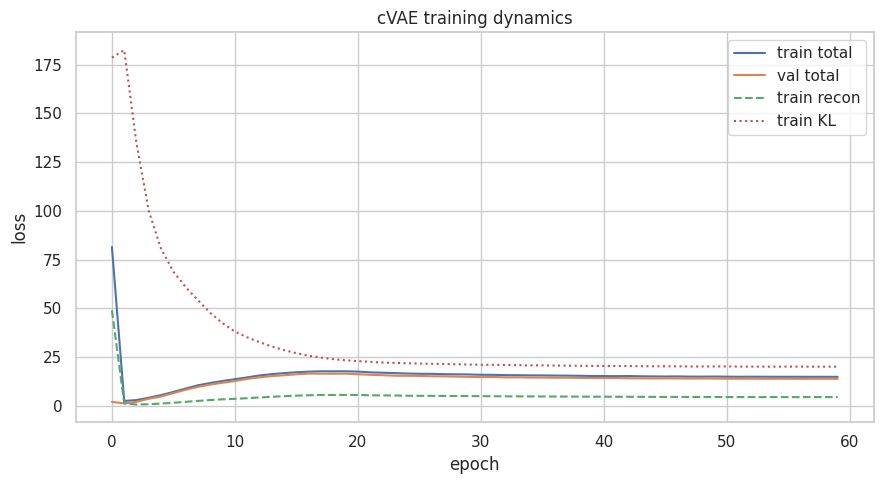

In [9]:
class FiLMBlock(nn.Module):
    """Residual block whose activations are modulated by the condition embedding."""
    def __init__(self, width, cond_dim, p_drop=0.10):
        super().__init__()
        self.fc = nn.Linear(width, width)
        self.act = nn.SiLU()
        self.drop = nn.Dropout(p_drop)
        self.gamma = nn.Linear(cond_dim, width)
        self.beta = nn.Linear(cond_dim, width)
    def forward(self, h, cemb):
        out = self.drop(self.act(self.fc(h)))
        out = self.gamma(cemb) * out + self.beta(cemb)
        return h + out

class CVAE(nn.Module):
    def __init__(self, x_dim, c_dim=4, latent=32, width=256, n_blocks=3, cond_dim=64):
        super().__init__()
        self.cond = nn.Sequential(nn.Linear(c_dim, cond_dim), nn.SiLU(),
                                  nn.Linear(cond_dim, cond_dim))
        self.null_emb = nn.Parameter(torch.zeros(cond_dim))
        self.enc_in = nn.Linear(x_dim, width)
        self.enc_blocks = nn.ModuleList([FiLMBlock(width, cond_dim) for _ in range(n_blocks)])
        self.mu = nn.Linear(width, latent)
        self.logvar = nn.Linear(width, latent)
        self.dec_in = nn.Linear(latent, width)
        self.dec_blocks = nn.ModuleList([FiLMBlock(width, cond_dim) for _ in range(n_blocks)])
        self.dec_out = nn.Linear(width, x_dim)
        self.latent = latent
    def embed(self, c, drop_mask=None):
        e = self.cond(c)
        if drop_mask is not None:
            e = torch.where(drop_mask.unsqueeze(1), self.null_emb.expand_as(e), e)
        return e
    def encode(self, x, cemb):
        h = self.enc_in(x)
        for b in self.enc_blocks:
            h = b(h, cemb)
        return self.mu(h), self.logvar(h)
    def decode(self, z, cemb):
        h = self.dec_in(z)
        for b in self.dec_blocks:
            h = b(h, cemb)
        return self.dec_out(h)
    def forward(self, x, c, p_uncond=0.10):
        mask = torch.rand(x.shape[0], device=x.device) < p_uncond
        cemb = self.embed(c, mask)
        mu, logvar = self.encode(x, cemb)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decode(z, cemb), mu, logvar, cemb
    @torch.no_grad()
    def generate(self, c_star, n, w=0.0, device=DEVICE):
        self.eval()
        c = torch.tensor(np.tile(c_star, (n, 1)), dtype=torch.float32, device=device)
        z = torch.randn(n, self.latent, device=device)
        e_cond = self.embed(c)
        e_null = self.null_emb.expand_as(e_cond)
        x = (1 + w) * self.decode(z, e_cond) - w * self.decode(z, e_null)
        return x.cpu().numpy()

def train_cvae(Xtr, Ctr, Xva, Cva, latent=32, width=256, epochs=60, batch=512,
               seed=SEED, beta_max=0.5, lam_mm=0.5, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model = CVAE(Xtr.shape[1], Ctr.shape[1], latent=latent, width=width).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    Xt = torch.tensor(np.asarray(Xtr), dtype=torch.float32)
    Ct = torch.tensor(np.asarray(Ctr), dtype=torch.float32)
    Xv = torch.tensor(np.asarray(Xva), dtype=torch.float32).to(DEVICE)
    Cv = torch.tensor(np.asarray(Cva), dtype=torch.float32).to(DEVICE)
    n = len(Xt)
    hist = {"train": [], "val": [], "recon": [], "kl": []}
    for ep in range(epochs):
        model.train()
        beta = beta_max * 0.5 * (1 - math.cos(math.pi * min(1.0, ep / (epochs / 3))))
        perm = torch.randperm(n)
        tot = rec_s = kl_s = 0.0
        for i in range(0, n, batch):
            idx = perm[i:i + batch]
            x = Xt[idx].to(DEVICE); c = Ct[idx].to(DEVICE)
            xhat, mu, logvar, cemb = model(x, c)
            rec = ((xhat - x) ** 2).sum(1).mean()
            kl = (-0.5 * (1 + logvar - mu ** 2 - logvar.exp()).sum(1)).mean()
            zp = torch.randn(x.shape[0], model.latent, device=DEVICE)
            xg = model.decode(zp, model.embed(c))
            mm = ((x.mean(0) - xg.mean(0)) ** 2).sum() + ((x.std(0) - xg.std(0)) ** 2).sum()
            loss = rec + beta * kl + lam_mm * mm
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            tot += loss.item() * len(idx); rec_s += rec.item() * len(idx); kl_s += kl.item() * len(idx)
        sched.step()
        model.eval()
        with torch.no_grad():
            xhat, mu, logvar, _ = model(Xv, Cv, p_uncond=0.0)
            vrec = ((xhat - Xv) ** 2).sum(1).mean().item()
            vkl = (-0.5 * (1 + logvar - mu ** 2 - logvar.exp()).sum(1)).mean().item()
        hist["train"].append(tot / n); hist["recon"].append(rec_s / n)
        hist["kl"].append(kl_s / n); hist["val"].append(vrec + beta * vkl)
        if verbose and (ep + 1) % 10 == 0:
            print(f"epoch {ep+1:3d}/{epochs}  train {hist['train'][-1]:.3f}  val {hist['val'][-1]:.3f}  beta {beta:.3f}")
    return model, hist

t0 = time.time()
cvae, hist = train_cvae(Xtr_q.values, Ctr_s, Xva_q.values, Cva_s)
print(f"cVAE trained in {time.time() - t0:.0f}s")

plt.figure(figsize=(9, 5))
plt.plot(hist["train"], label="train total")
plt.plot(hist["val"], label="val total")
plt.plot(hist["recon"], label="train recon", ls="--")
plt.plot(hist["kl"], label="train KL", ls=":")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("cVAE training dynamics")
plt.tight_layout(); save_show("fig15_cvae_training_curve.png")

## Section 10 — Target operating points, CFG guidance sweep, hit-rates vs baselines (figs 16–17)

Target operating points:
                         Voc       Jsc      FF  PCE_proxy
Median               1.2652 -212.3088  0.7399     0.1919
High-PCE (90th pct)  1.3513 -216.1448  0.8765     0.2460
Top-tier (99th pct)  1.3739 -217.9303  0.9028     0.2609
Ultra (101% of top)  1.3876 -220.1096  0.9118     0.2635

CFG sweep (Top-tier target):
      w  hit_rate  mean_PCE
0  0.0     0.034  0.237850
1  0.5     0.085  0.243474
2  1.0     0.122  0.247649
3  1.5     0.155  0.249426
4  2.0     0.135  0.249313
5  3.0     0.112  0.249107
6  5.0     0.041  0.246521
7  7.0     0.015  0.244593
optimal guidance scale w* = 1.5


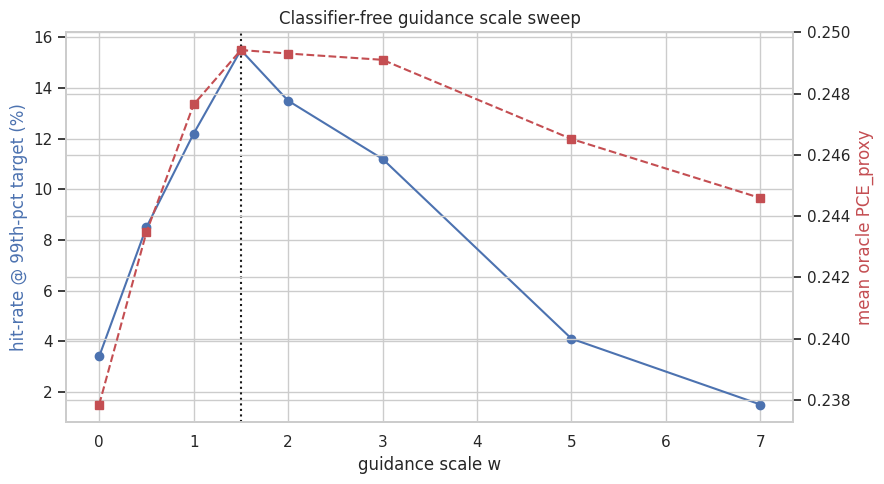


Inverse-design hit-rates:
              target  PCE_threshold  cVAE+CFG  cVAE (w=0)  random  lift_vs_random
             Median         0.1919     0.614       0.559   0.481          1.2765
High-PCE (90th pct)         0.2460     0.737       0.390   0.083          8.8795
Top-tier (99th pct)         0.2609     0.126       0.030   0.005         25.2000
Ultra (101% of top)         0.2635     0.034       0.014   0.000         34.0000


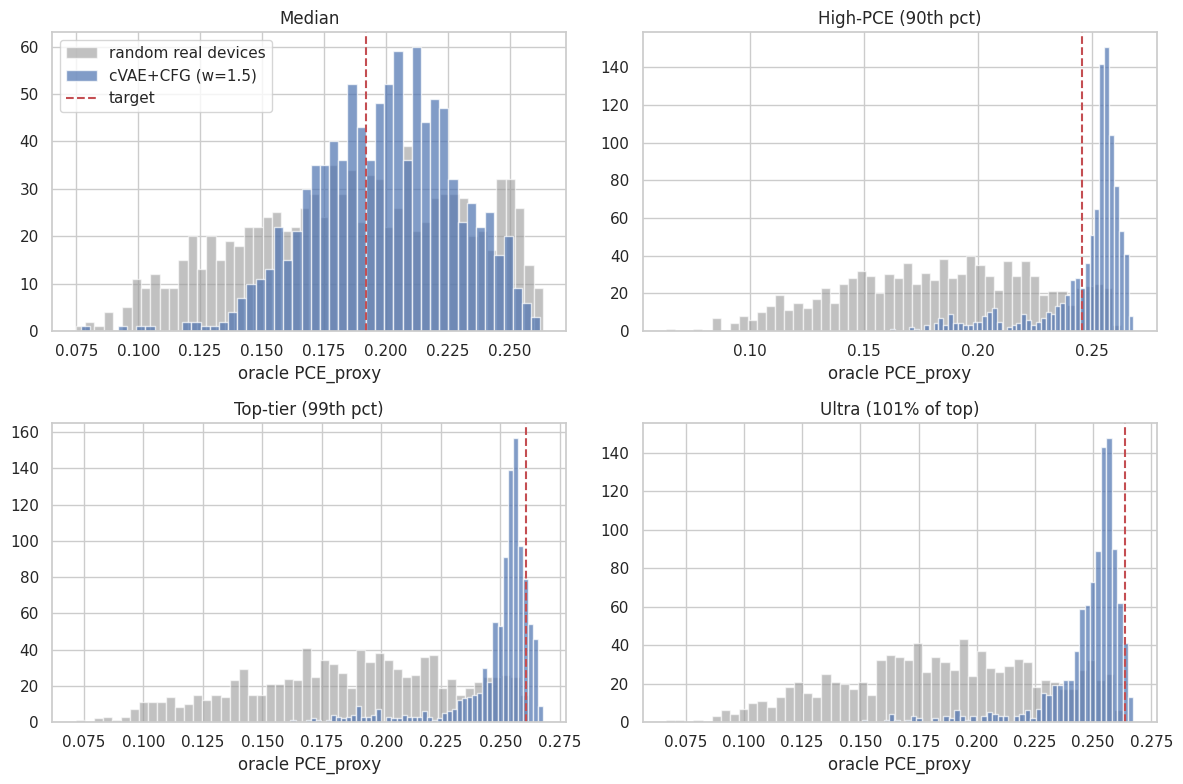

In [10]:
Cdf = pd.DataFrame(C_raw, columns=["Voc", "Jsc", "FF", "PCE"])
def target_vec(q_hi):
    q_lo = 1 - q_hi
    return np.array([Cdf["Voc"].quantile(q_hi), Cdf["Jsc"].quantile(q_lo),
                     Cdf["FF"].quantile(q_hi), Cdf["PCE"].quantile(q_hi)])
TOP99 = target_vec(0.99)
TARGET_SPECS = {
    "Median": target_vec(0.50),
    "High-PCE (90th pct)": target_vec(0.90),
    "Top-tier (99th pct)": TOP99,
    "Ultra (101% of top)": TOP99 * 1.01,
}
tgt_table = pd.DataFrame(TARGET_SPECS, index=["Voc", "Jsc", "FF", "PCE_proxy"]).T
print("Target operating points:\n", tgt_table.round(4))

N_GEN = 1000
def gen_and_score(model, c_star_raw, w, n=N_GEN):
    c_std = CSC.transform(c_star_raw.reshape(1, -1))[0]
    Xg = model.generate(c_std, n, w=w)
    return Xg, oracle_pce(Xg)

# fig16 — guidance-scale sweep at the 99th-percentile target
W_LIST = [0, 0.5, 1, 1.5, 2, 3, 5, 7]
sweep = []
for w in W_LIST:
    _, pce = gen_and_score(cvae, TOP99, w)
    sweep.append({"w": w, "hit_rate": float((pce >= TOP99[3]).mean()), "mean_PCE": float(pce.mean())})
sweep = pd.DataFrame(sweep)
print("\nCFG sweep (Top-tier target):\n", sweep)
W_STAR = float(sweep.loc[sweep["hit_rate"].idxmax(), "w"])
print("optimal guidance scale w* =", W_STAR)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(sweep["w"], 100 * sweep["hit_rate"], "o-", color="#4C72B0", label="hit-rate")
ax1.set_xlabel("guidance scale w"); ax1.set_ylabel("hit-rate @ 99th-pct target (%)", color="#4C72B0")
ax2 = ax1.twinx()
ax2.plot(sweep["w"], sweep["mean_PCE"], "s--", color="#C44E52", label="mean oracle PCE")
ax2.set_ylabel("mean oracle PCE_proxy", color="#C44E52")
ax1.axvline(W_STAR, ls=":", c="k")
plt.title("Classifier-free guidance scale sweep")
plt.tight_layout(); save_show("fig16_cfg_guidance_sweep.png")

# Hit-rate comparison against baselines
rand_pool = Xtr_q.values
hit_rows, GEN_CACHE = [], {}
for tname, c_star in TARGET_SPECS.items():
    thr = c_star[3]
    Xg_cfg, pce_cfg = gen_and_score(cvae, c_star, W_STAR)
    _, pce_unc = gen_and_score(cvae, c_star, 0.0)
    ridx = rng.choice(len(rand_pool), N_GEN, replace=False)
    pce_rnd = oracle_pce(rand_pool[ridx])
    GEN_CACHE[tname] = (Xg_cfg, pce_cfg, pce_rnd)
    hr_cfg, hr_unc, hr_rnd = [float((p >= thr).mean()) for p in (pce_cfg, pce_unc, pce_rnd)]
    lift = hr_cfg / max(hr_rnd, 1.0 / N_GEN)
    hit_rows.append({"target": tname, "PCE_threshold": thr, "cVAE+CFG": hr_cfg,
                     "cVAE (w=0)": hr_unc, "random": hr_rnd, "lift_vs_random": lift})
hit_table = pd.DataFrame(hit_rows)
print("\nInverse-design hit-rates:\n", hit_table.round(4).to_string(index=False))

# fig17 — oracle-PCE histograms per target
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (tname, (Xg, pce_cfg, pce_rnd)) in zip(axes.ravel(), GEN_CACHE.items()):
    ax.hist(pce_rnd, bins=50, alpha=0.6, label="random real devices", color="#999999")
    ax.hist(pce_cfg, bins=50, alpha=0.7, label=f"cVAE+CFG (w={W_STAR})", color="#4C72B0")
    ax.axvline(TARGET_SPECS[tname][3], c="r", ls="--", label="target")
    ax.set_title(tname); ax.set_xlabel("oracle PCE_proxy")
axes[0, 0].legend()
plt.tight_layout(); save_show("fig17_oracle_pce_histograms.png")

## Section 11 — Physical plausibility: KS tests + marginal overlays (fig 18)

KS test (real vs generated, 99th-pct target) — most preserved marginals first:
                 feature  KS_stat       p_value
                phi_asym   0.0290  4.791928e-01
                   Etrap   0.0540  1.511308e-02
                phi_diff   0.0918  1.497300e-06
                phi_left   0.1358  7.630128e-14
                   mun_0   0.1578  1.461797e-18
                   mup_0   0.1806  3.270655e-24
interface_thickness_frac   0.1856  1.483555e-25
          mobility_ratio   0.2118  3.268538e-33
               phi_right   0.2342  1.373492e-40
                phi_mean   0.2446  2.819404e-44
                  Rshunt   0.2612  1.641982e-50
   total_interface_traps   0.2814  1.107440e-58
                  mob_IL   0.3226  2.260811e-77
            doping_right   0.3894 1.182365e-113
                  IR_dop   0.3952 3.640673e-117

features with p > 0.05 (marginal preserved): 1/32


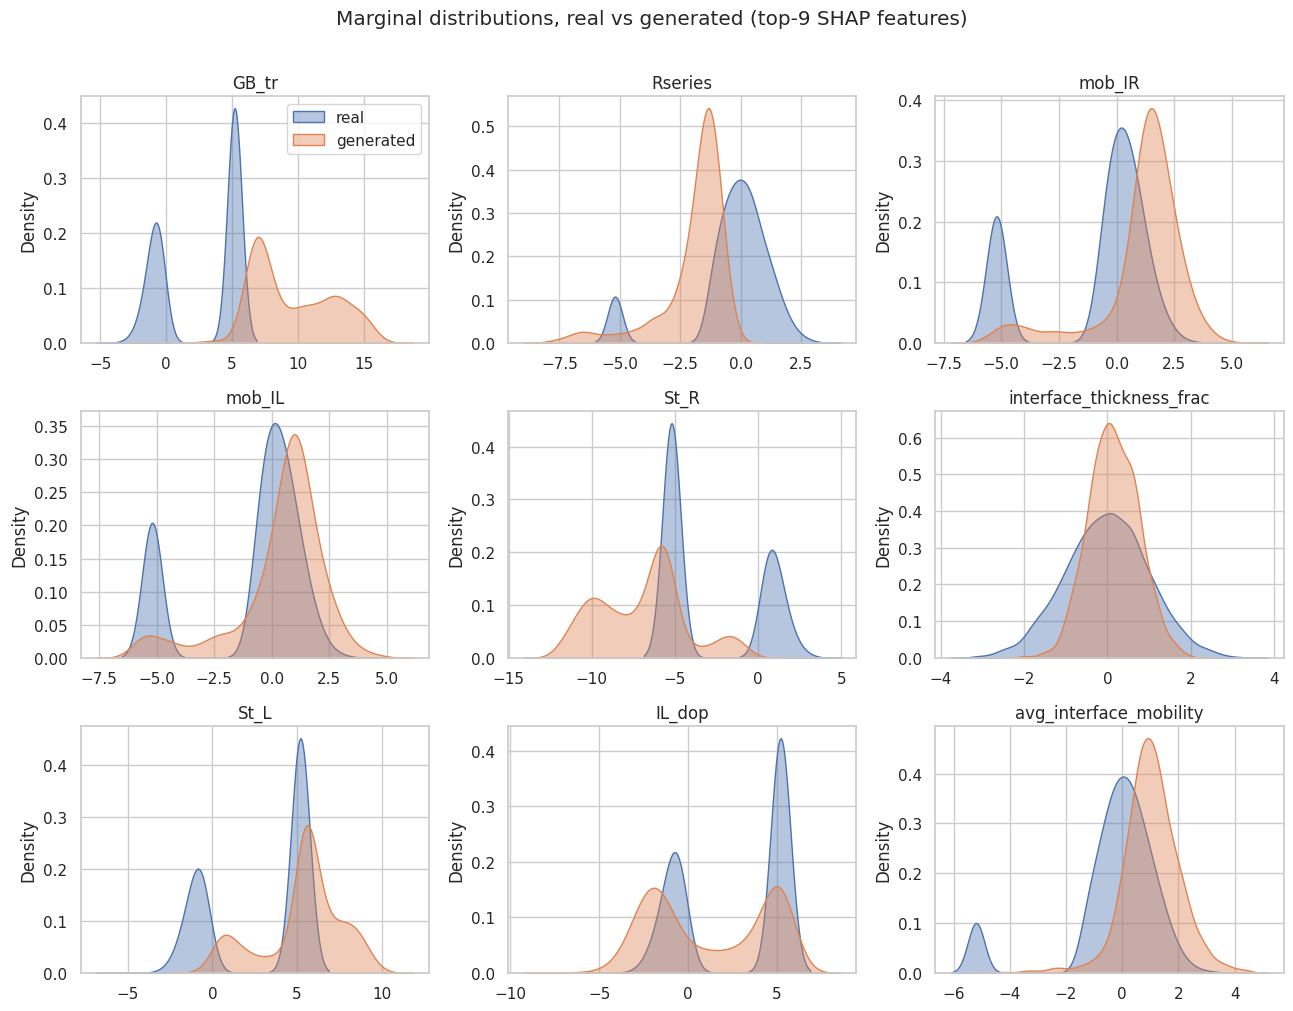

In [11]:
Xg99 = GEN_CACHE["Top-tier (99th pct)"][0]
real_ref = Xva_q.sample(5000, random_state=SEED)
ks_rows = []
for j, f in enumerate(FEATURES):
    s, p = stats.ks_2samp(real_ref[f].values, Xg99[:, j])
    ks_rows.append({"feature": f, "KS_stat": s, "p_value": p})
ks_table = pd.DataFrame(ks_rows).sort_values("KS_stat")
print("KS test (real vs generated, 99th-pct target) — most preserved marginals first:")
print(ks_table.head(15).to_string(index=False))
print(f"\nfeatures with p > 0.05 (marginal preserved): {(ks_table['p_value'] > 0.05).sum()}/{len(FEATURES)}")

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, f in zip(axes.ravel(), SHAP_RANK.head(9).index):
    j = FEATURES.index(f)
    sns.kdeplot(real_ref[f], ax=ax, label="real", fill=True, alpha=0.4)
    sns.kdeplot(Xg99[:, j], ax=ax, label="generated", fill=True, alpha=0.4)
    ax.set_title(f); ax.set_xlabel("")
axes[0, 0].legend()
fig.suptitle("Marginal distributions, real vs generated (top-9 SHAP features)", y=1.01)
plt.tight_layout(); save_show("fig18_marginal_distributions_real_vs_generated.png")

## Section 12 — Final result-analysis table (fig 19)

         Stage                Item                         Result                         Detail
  Surrogate CV                 XGB           R2 = 0.8661 ± 0.0020 RMSE = 0.01715 | MAE = 0.01274
  Surrogate CV                LGBM           R2 = 0.8661 ± 0.0021 RMSE = 0.01716 | MAE = 0.01274
  Surrogate CV                 GBR           R2 = 0.8516 ± 0.0023 RMSE = 0.01806 | MAE = 0.01349
  Surrogate CV                  RF           R2 = 0.8301 ± 0.0022 RMSE = 0.01933 | MAE = 0.01438
  Surrogate CV                  ET           R2 = 0.8237 ± 0.0012 RMSE = 0.01969 | MAE = 0.01471
  Surrogate CV                 MLP           R2 = 0.7178 ± 0.0134 RMSE = 0.02490 | MAE = 0.01887
  Surrogate CV               Ridge           R2 = 0.4607 ± 0.0039 RMSE = 0.03443 | MAE = 0.02764
    Statistics       XGB vs others      Wilcoxon p max = 5.05e-01      paired-t p max = 9.24e-01
           XAI  Top drivers (SHAP) GB_tr, Rseries, mob_IR, mob_IL                               
           CFG    optimal guid

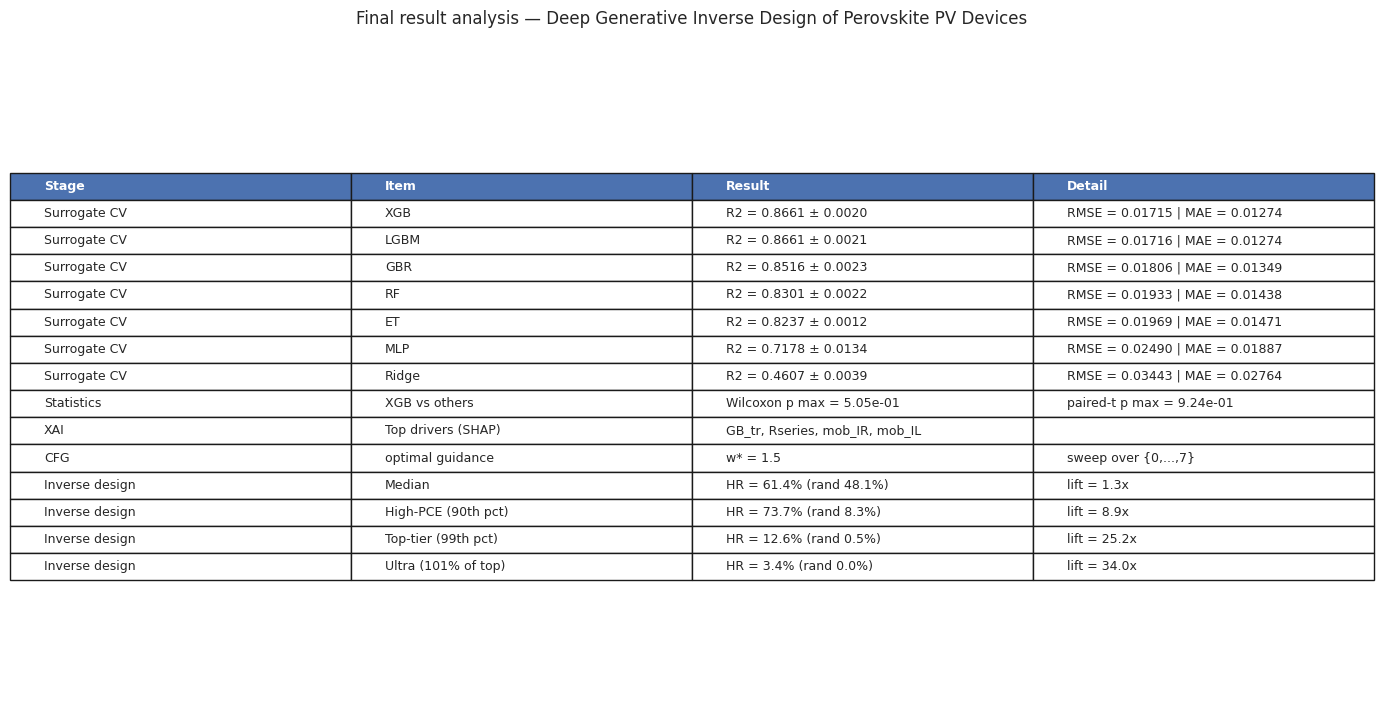

In [12]:
summary_rows = []
for m in cv_table.index:
    summary_rows.append(["Surrogate CV", m,
                         f"R2 = {cv_table.loc[m, 'R2_mean']:.4f} ± {cv_table.loc[m, 'R2_std']:.4f}",
                         f"RMSE = {cv_table.loc[m, 'RMSE_mean']:.5f} | MAE = {cv_table.loc[m, 'MAE_mean']:.5f}"])
summary_rows.append(["Statistics", f"{BEST} vs others",
                     f"Wilcoxon p max = {stat_table['wilcoxon_p'].max():.2e}",
                     f"paired-t p max = {stat_table['paired_t_p'].max():.2e}"])
summary_rows.append(["XAI", "Top drivers (SHAP)", ", ".join(SHAP_RANK.head(4).index), ""])
summary_rows.append(["CFG", "optimal guidance", f"w* = {W_STAR}", "sweep over {0,...,7}"])
for _, r in hit_table.iterrows():
    summary_rows.append(["Inverse design", r["target"],
                         f"HR = {100 * r['cVAE+CFG']:.1f}% (rand {100 * r['random']:.1f}%)",
                         f"lift = {r['lift_vs_random']:.1f}x"])
summary_df = pd.DataFrame(summary_rows, columns=["Stage", "Item", "Result", "Detail"])
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 0.45 * len(summary_df) + 1))
ax.axis("off")
tbl = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
               cellLoc="left", colLoc="left", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.4)
for k in range(len(summary_df.columns)):
    tbl[0, k].set_facecolor("#4C72B0"); tbl[0, k].set_text_props(color="white", weight="bold")
plt.title("Final result analysis — Deep Generative Inverse Design of Perovskite PV Devices", pad=18)
plt.tight_layout(); save_show("fig19_final_result_analysis_table.png")

---
# Part B — Revision experiments (reviewer responses)
Everything below is **new for the revision**. Figures are saved as `figR01`–`figR05`.

## Section 13 — Per-class SHAP + per-class permutation importance (R2.5, R3.2; figs R01–R02)
Reviewer 2 #5 asks whether the dominant PCE-limiting factors hold across the three recombination classes.
Reviewer 3 #2 asks about the GB_tr discrepancy between SHAP and permutation importance.

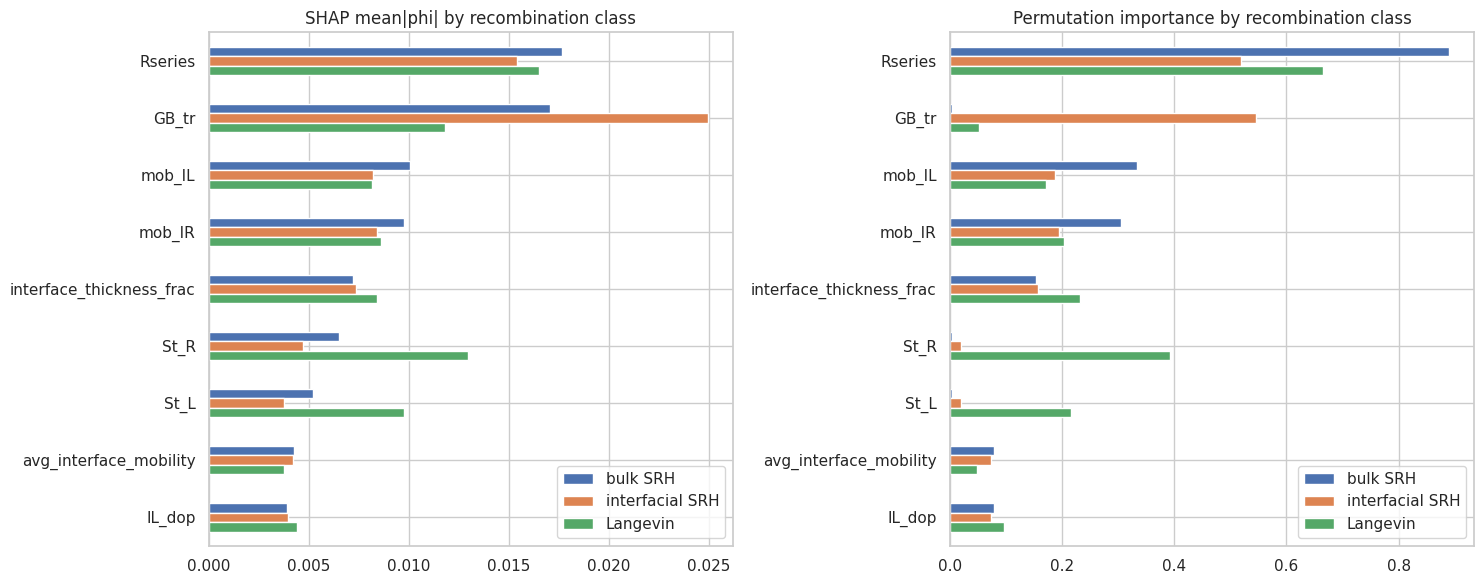

Rank of key features per class (SHAP | permutation):
  Rseries  [bulk SRH        ]  SHAP # 1 | perm # 1
  Rseries  [interfacial SRH ]  SHAP # 2 | perm # 2
  Rseries  [Langevin        ]  SHAP # 1 | perm # 1
  GB_tr    [bulk SRH        ]  SHAP # 2 | perm #15
  GB_tr    [interfacial SRH ]  SHAP # 1 | perm # 1
  GB_tr    [Langevin        ]  SHAP # 3 | perm #10
  St_L     [bulk SRH        ]  SHAP # 7 | perm #13
  St_L     [interfacial SRH ]  SHAP # 9 | perm #12
  St_L     [Langevin        ]  SHAP # 4 | perm # 4
  St_R     [bulk SRH        ]  SHAP # 6 | perm #12
  St_R     [interfacial SRH ]  SHAP # 6 | perm #13
  St_R     [Langevin        ]  SHAP # 2 | perm # 2

|correlation| of GB_tr with other features (redundancy explains SHAP-vs-perm gap):
GB_tr      1.000000
St_R       0.079323
St_L       0.073036
Rshunt     0.062572
Rseries    0.056274
mob_IL     0.047799
Name: GB_tr, dtype: float64


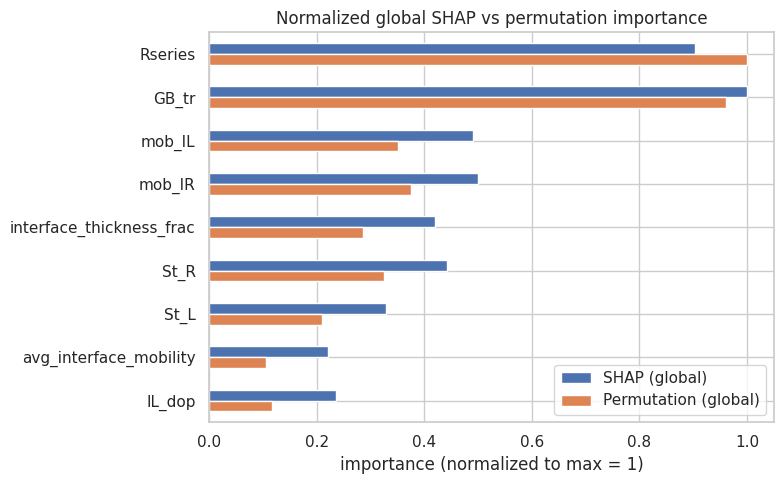

In [13]:
per_class_shap, per_class_perm = {}, {}
for k in sorted(np.unique(lab_va)):
    sub_rows = Xva_q[lab_va == k]
    samp = sub_rows.sample(min(1500, len(sub_rows)), random_state=SEED)
    sv_k = explainer.shap_values(samp)
    per_class_shap[CLASS_NAMES[k]] = pd.Series(np.abs(sv_k).mean(0), index=FEATURES)
    y_k = yva[lab_va == k]
    samp_idx = np.arange(len(sub_rows))[:4000]
    pi_k = permutation_importance(best_model, sub_rows.iloc[samp_idx], y_k[samp_idx],
                                  n_repeats=5, random_state=SEED, n_jobs=-1)
    per_class_perm[CLASS_NAMES[k]] = pd.Series(pi_k.importances_mean, index=FEATURES)

shap_by_class = pd.DataFrame(per_class_shap)
perm_by_class = pd.DataFrame(per_class_perm)
top_union = list(pd.concat([s.sort_values(ascending=False).head(8) for s in per_class_shap.values()]).index.unique())[:12]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
shap_by_class.loc[top_union].plot.barh(ax=axes[0])
axes[0].invert_yaxis(); axes[0].set_title("SHAP mean|phi| by recombination class")
perm_by_class.loc[top_union].plot.barh(ax=axes[1])
axes[1].invert_yaxis(); axes[1].set_title("Permutation importance by recombination class")
plt.tight_layout(); save_show("figR01_xai_by_class.png")

def rank_of(series, feat):
    return int(series.sort_values(ascending=False).index.get_loc(feat)) + 1

print("Rank of key features per class (SHAP | permutation):")
for f in ["Rseries", "GB_tr", "St_L", "St_R"]:
    if f in FEATURES:
        for cls in shap_by_class.columns:
            print(f"  {f:8s} [{cls:16s}]  SHAP #{rank_of(shap_by_class[cls], f):2d} | perm #{rank_of(perm_by_class[cls], f):2d}")

# GB_tr discrepancy: correlation of GB_tr with its engineered derivatives explains
# why permutation (which breaks one column at a time) undervalues correlated features.
gb_corr = Xtr_q.corr()["GB_tr"].abs().sort_values(ascending=False).head(6)
print("\n|correlation| of GB_tr with other features (redundancy explains SHAP-vs-perm gap):")
print(gb_corr)

fig, ax = plt.subplots(figsize=(8, 5))
comp = pd.DataFrame({"SHAP (global)": SHAP_RANK, "Permutation (global)": PERM_RANK}).loc[top_union]
comp = comp / comp.max()  # normalize for shape comparison
comp.plot.barh(ax=ax); ax.invert_yaxis()
ax.set_title("Normalized global SHAP vs permutation importance")
ax.set_xlabel("importance (normalized to max = 1)")
plt.tight_layout(); save_show("figR02_shap_vs_perm_global.png")

## Section 14 — Robustness of the guidance-scale optimum (R2.8; fig R03)
Retrains the cVAE under different seeds/splits and repeats the guidance sweep at three targets.
~15–25 min on GPU.

seed 7: cVAE + oracle retrained
seed 2026: cVAE + oracle retrained

Guidance-scale robustness:
  seed              target  optimal_w  hit_rate_at_w3  best_hit_rate
   42 High-PCE (90th pct)        2.0           0.765          0.772
   42 Top-tier (99th pct)        1.5           0.112          0.154
   42 Ultra (101% of top)        1.0           0.026          0.045
    7 High-PCE (90th pct)        1.5           0.766          0.796
    7 Top-tier (99th pct)        1.5           0.042          0.083
    7 Ultra (101% of top)        1.0           0.004          0.009
 2026 High-PCE (90th pct)        1.5           0.737          0.773
 2026 Top-tier (99th pct)        1.5           0.063          0.103
 2026 Ultra (101% of top)        0.5           0.009          0.014

optimal w per target (mean ± sd over seeds):
                         mean       std
target                                 
High-PCE (90th pct)  1.666667  0.288675
Top-tier (99th pct)  1.500000  0.000000
Ultra (101% of top

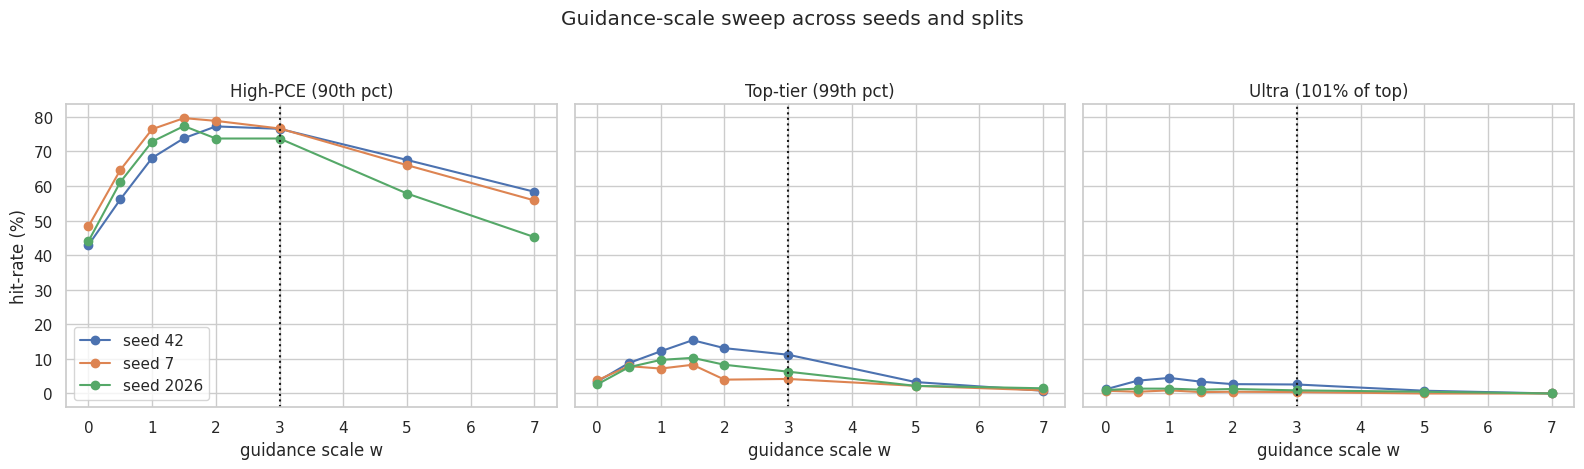

In [14]:
ROBUST_SEEDS = [42, 7, 2026]
ROBUST_TARGETS = {k: TARGET_SPECS[k] for k in ["High-PCE (90th pct)", "Top-tier (99th pct)", "Ultra (101% of top)"]}
robust_rows = []
sweep_curves = {}
for s in ROBUST_SEEDS:
    if s == SEED:
        model_s, qt_s, csc_s, oracle_s = cvae, QT, CSC, oracle_pce
        Xtr_s = Xtr_q.values
    else:
        tr_s, va_s = train_test_split(np.arange(len(X_all)), test_size=0.2, stratify=lab, random_state=s)
        qt_s = QuantileTransformer(n_quantiles=1000, output_distribution="normal",
                                   subsample=200000, random_state=s).fit(X_all.iloc[tr_s])
        Xtr_s = qt_s.transform(X_all.iloc[tr_s]); Xva_s = qt_s.transform(X_all.iloc[va_s])
        csc_s = StandardScaler().fit(C_raw[tr_s])
        oracle_members = []
        for name in TOP3:
            m = make_models()[name]; m.fit(Xtr_s, y_all[tr_s]); oracle_members.append(m)
        def oracle_s(X, _members=oracle_members):
            return np.mean([m.predict(X) for m in _members], axis=0)
        model_s, _ = train_cvae(Xtr_s, csc_s.transform(C_raw[tr_s]),
                                Xva_s, csc_s.transform(C_raw[va_s]), seed=s, verbose=False)
        print(f"seed {s}: cVAE + oracle retrained")
    for tname, c_star in ROBUST_TARGETS.items():
        thr = c_star[3]
        hrs = []
        for w in W_LIST:
            Xg = model_s.generate(csc_s.transform(c_star.reshape(1, -1))[0], N_GEN, w=w)
            hrs.append(float((oracle_s(Xg) >= thr).mean()))
        sweep_curves[(s, tname)] = hrs
        w_opt = W_LIST[int(np.argmax(hrs))]
        robust_rows.append({"seed": s, "target": tname, "optimal_w": w_opt,
                            "hit_rate_at_w3": hrs[W_LIST.index(3)], "best_hit_rate": max(hrs)})
robust_table = pd.DataFrame(robust_rows)
print("\nGuidance-scale robustness:\n", robust_table.to_string(index=False))
print("\noptimal w per target (mean ± sd over seeds):")
print(robust_table.groupby("target")["optimal_w"].agg(["mean", "std"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, tname in zip(axes, ROBUST_TARGETS):
    for s in ROBUST_SEEDS:
        ax.plot(W_LIST, [100 * h for h in sweep_curves[(s, tname)]], "o-", label=f"seed {s}")
    ax.axvline(3, ls=":", c="k"); ax.set_title(tname); ax.set_xlabel("guidance scale w")
axes[0].set_ylabel("hit-rate (%)"); axes[0].legend()
fig.suptitle("Guidance-scale sweep across seeds and splits", y=1.04)
plt.tight_layout(); save_show("figR03_guidance_robustness.png")

## Section 15 — Architecture sensitivity: latent dim × width grid (R2.10; fig R04)
30-epoch runs (vs 60 in production) purely for sensitivity ranking. ~15 min on GPU.

latent   8 width 128: hit-rate 0.007, val loss 18.037
latent   8 width 256: hit-rate 0.010, val loss 15.727
latent   8 width 512: hit-rate 0.000, val loss 14.591
latent  16 width 128: hit-rate 0.007, val loss 16.970
latent  16 width 256: hit-rate 0.123, val loss 15.067
latent  16 width 512: hit-rate 0.072, val loss 13.654
latent  32 width 128: hit-rate 0.110, val loss 17.752
latent  32 width 256: hit-rate 0.113, val loss 15.112
latent  32 width 512: hit-rate 0.043, val loss 13.802
latent  64 width 128: hit-rate 0.093, val loss 17.241
latent  64 width 256: hit-rate 0.121, val loss 15.361
latent  64 width 512: hit-rate 0.081, val loss 14.124


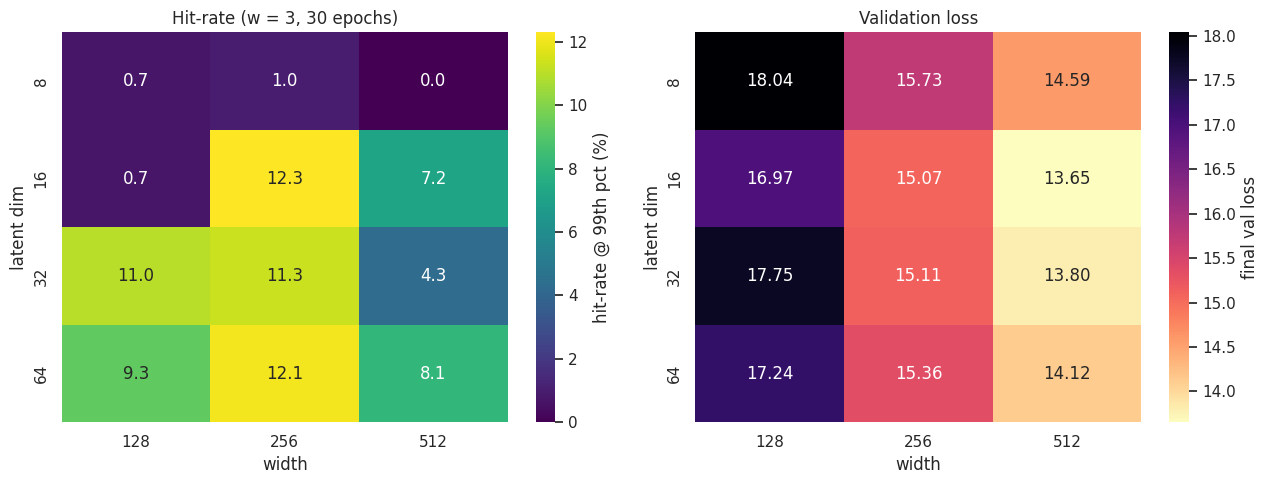

In [15]:
LATENTS = [8, 16, 32, 64]
WIDTHS = [128, 256, 512]
hr_grid = pd.DataFrame(index=LATENTS, columns=WIDTHS, dtype=float)
rec_grid = pd.DataFrame(index=LATENTS, columns=WIDTHS, dtype=float)
for ld in LATENTS:
    for wd in WIDTHS:
        m, h = train_cvae(Xtr_q.values, Ctr_s, Xva_q.values, Cva_s,
                          latent=ld, width=wd, epochs=30, verbose=False)
        Xg = m.generate(CSC.transform(TOP99.reshape(1, -1))[0], N_GEN, w=3.0)
        hr_grid.loc[ld, wd] = float((oracle_pce(Xg) >= TOP99[3]).mean())
        rec_grid.loc[ld, wd] = h["val"][-1]
        print(f"latent {ld:3d} width {wd:3d}: hit-rate {hr_grid.loc[ld, wd]:.3f}, val loss {rec_grid.loc[ld, wd]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(100 * hr_grid.astype(float), annot=True, fmt=".1f", cmap="viridis", ax=axes[0],
            cbar_kws={"label": "hit-rate @ 99th pct (%)"})
axes[0].set_xlabel("width"); axes[0].set_ylabel("latent dim"); axes[0].set_title("Hit-rate (w = 3, 30 epochs)")
sns.heatmap(rec_grid.astype(float), annot=True, fmt=".2f", cmap="magma_r", ax=axes[1],
            cbar_kws={"label": "final val loss"})
axes[1].set_xlabel("width"); axes[1].set_ylabel("latent dim"); axes[1].set_title("Validation loss")
plt.tight_layout(); save_show("figR04_architecture_sensitivity.png")

## Section 16 — Validity, uniqueness, novelty of generated devices (R3.5)

In [16]:
BASE_FEATS = [c for c in FEATURES if c in DEVICE_COLS]

def to_physical(Xq):
    """Invert quantile normalization and the signed-log transform back to physical units."""
    inv = pd.DataFrame(QT.inverse_transform(Xq), columns=FEATURES)
    for c in SKEWED:
        if c in inv.columns and SKEWED_POSITIVE.get(c, False):
            inv[c] = np.power(10.0, inv[c])  # strictly-positive quantity: sign(x) = +1
    return inv

phys_train = df[BASE_FEATS]
lo, hi = phys_train.min(), phys_train.max()
tol = 0.001 * (hi - lo)  # additive tolerance, sign-safe for negative-valued parameters
nn_ref = NearestNeighbors(n_neighbors=2).fit(Xtr_q.values[:20000])
d_train, _ = nn_ref.kneighbors(Xtr_q.values[:5000])
train_nn_median = np.median(d_train[:, 1])  # distance to nearest *other* training point

vun_rows = []
for tname, (Xg, pce_cfg, _) in GEN_CACHE.items():
    phys = to_physical(Xg)[BASE_FEATS]
    valid = ((phys >= lo - tol) & (phys <= hi + tol)).all(axis=1).mean()
    uniq = 1.0 - pd.DataFrame(np.round(Xg, 3)).duplicated().mean()
    d_gen, _ = nn_ref.kneighbors(Xg)
    novelty_exact = float((d_gen[:, 0] > 1e-6).mean())
    novelty_beyond = float((d_gen[:, 0] > train_nn_median).mean())
    vun_rows.append({"target": tname, "validity": valid, "uniqueness": uniq,
                     "novelty (not a copy)": novelty_exact,
                     "novelty (beyond train NN median)": novelty_beyond,
                     "mean NN distance": float(d_gen[:, 0].mean())})
vun_table = pd.DataFrame(vun_rows)
print("Generative-model quality metrics (1,000 candidates per target):")
print(vun_table.round(4).to_string(index=False))
print(f"\n(reference: median nearest-neighbour distance within training set = {train_nn_median:.3f})")
print("Note: validity is high by construction — the rank-based inverse transform maps candidates")
print("back inside the empirical parameter ranges, so every generated device is realizable within")
print("the simulated design space. State this explicitly in the response to R3.5.")

Generative-model quality metrics (1,000 candidates per target):
             target  validity  uniqueness  novelty (not a copy)  novelty (beyond train NN median)  mean NN distance
             Median       1.0         1.0                   1.0                             0.937            5.2757
High-PCE (90th pct)       1.0         1.0                   1.0                             0.996            7.3169
Top-tier (99th pct)       1.0         1.0                   1.0                             0.998            8.5625
Ultra (101% of top)       1.0         1.0                   1.0                             1.000           10.0328

(reference: median nearest-neighbour distance within training set = 3.427)
Note: validity is high by construction — the rank-based inverse transform maps candidates
back inside the empirical parameter ranges, so every generated device is realizable within
the simulated design space. State this explicitly in the response to R3.5.


## Section 17 — Representative generated device recipes + SIMsalabim export (R3.4, R2.1; fig R05)
Top candidates in physical units. The CSV `generated_candidates_for_resimulation.csv` is the input for drift-diffusion re-validation, which directly answers R2.1/R2.7.

saved top-100 candidates -> /kaggle/working/generated_candidates_for_resimulation.csv

Top-10 generated device recipes (physical units):
          L     mun_0     mup_0   Rseries Rshunt GB_tr St_L St_R  Etrap phi_left phi_right oracle_PCE_proxy
0  7.18e-07    0.0111  8.95e-05  3.63e-06   2.51     0    0    0  0.471      0.1    0.0818            0.268
1  4.81e-07   0.00526  6.59e-05  1.39e-06   6.81     0    0    0  0.743   0.0222    0.0261            0.268
2   5.9e-07    0.0238  9.12e-05  1.39e-06   4.78     0    0    0  0.413   0.0115   0.00197            0.268
3  6.96e-07    0.0314  0.000117  1.39e-06   91.9     0    0    0  0.523     0.02    0.0612            0.268
4  7.14e-07  0.000743    0.0004   1.9e-06   16.6     0    0    0  0.685    0.041    0.0428            0.267
5  4.21e-07  0.000199   0.00657         0  1e+03     0    0    0  0.753   0.0968     0.167            0.267
6  7.17e-07   0.00675  7.99e-05   2.2e-06   49.6     0    0    0  0.471   0.0723    0.0692            0.266

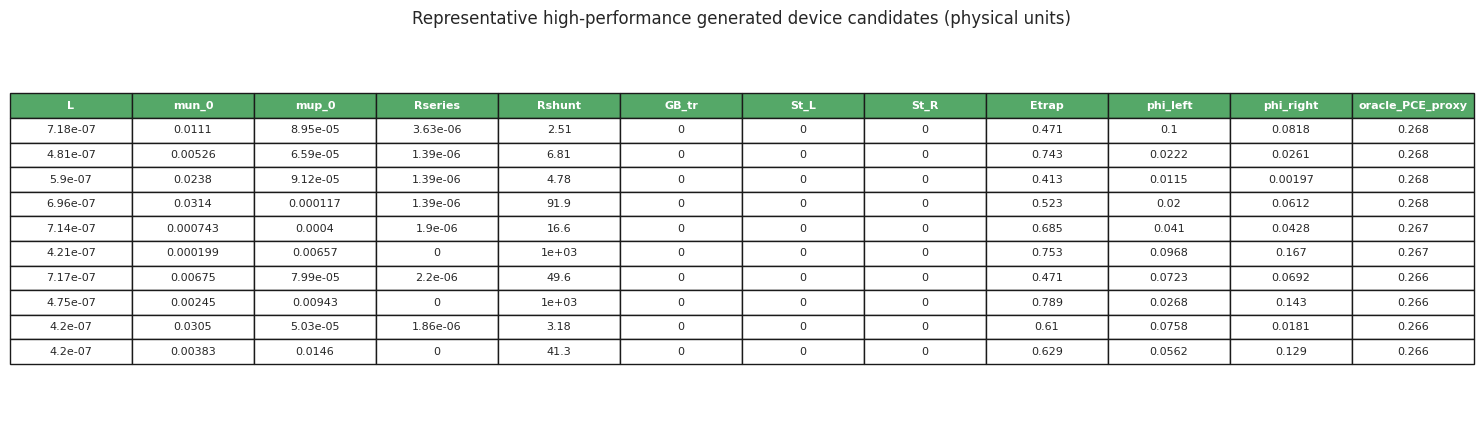

In [17]:
Xg99, pce99, _ = GEN_CACHE["Top-tier (99th pct)"]
phys99 = to_physical(Xg99)
phys99["oracle_PCE_proxy"] = pce99
top100 = phys99.sort_values("oracle_PCE_proxy", ascending=False).head(100)
out_csv = os.path.join(os.path.dirname(FIGDIR) or ".", "generated_candidates_for_resimulation.csv")
top100[BASE_FEATS + ["oracle_PCE_proxy"]].to_csv(out_csv, index=False)
print(f"saved top-100 candidates -> {out_csv}")

show_cols = [c for c in ["L", "mun_0", "mup_0", "Rseries", "Rshunt", "GB_tr",
                         "St_L", "St_R", "Etrap", "phi_left", "phi_right"] if c in phys99.columns]
top10 = top100.head(10)[show_cols + ["oracle_PCE_proxy"]].reset_index(drop=True)
disp = top10.copy()
for c in disp.columns:
    disp[c] = disp[c].map(lambda v: f"{v:.3g}")
print("\nTop-10 generated device recipes (physical units):")
print(disp.to_string())

fig, ax = plt.subplots(figsize=(15, 4.4))
ax.axis("off")
tbl = ax.table(cellText=disp.values, colLabels=disp.columns, cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.35)
for k in range(len(disp.columns)):
    tbl[0, k].set_facecolor("#55A868"); tbl[0, k].set_text_props(color="white", weight="bold")
plt.title("Representative high-performance generated device candidates (physical units)", pad=14)
plt.tight_layout(); save_show("figR05_generated_candidates.png")

## Section 18 — Practical significance: effect sizes alongside p-values (R2.4)

In [18]:
med_pce = float(np.median(y_all))
eff_rows = []
for other in [m for m in MODEL_NAMES if m != BEST]:
    diff = abs_err[other] - abs_err[BEST]  # positive = BEST better
    d_cohen = diff.mean() / diff.std()
    n = len(diff)
    w_stat, _ = stats.wilcoxon(abs_err[BEST], abs_err[other])
    r_rb = 1 - (2 * w_stat) / (n * (n + 1) / 2)  # rank-biserial correlation
    eff_rows.append({"comparison": f"{BEST} vs {other}",
                     "dMAE (PCE units)": diff.mean(),
                     "dMAE (% of median PCE)": 100 * diff.mean() / med_pce,
                     "Cohen_d": d_cohen, "rank_biserial_r": r_rb})
eff_table = pd.DataFrame(eff_rows)
print("Effect sizes for the surrogate comparison (practical significance):")
print(eff_table.round(4).to_string(index=False))
print("\nInterpretation: |d| < 0.2 small, 0.2-0.5 medium... the absolute MAE gap in PCE units and")
print("as % of the median PCE is the practically relevant quantity to quote in the response letter.")

Effect sizes for the surrogate comparison (practical significance):
  comparison  dMAE (PCE units)  dMAE (% of median PCE)  Cohen_d  rank_biserial_r
XGB vs Ridge            0.0149                  7.7617   0.7202           0.7027
  XGB vs MLP            0.0061                  3.1949   0.4180           0.4463
   XGB vs RF            0.0016                  0.8518   0.2007           0.2087
   XGB vs ET            0.0020                  1.0268   0.2258           0.2376
  XGB vs GBR            0.0007                  0.3890   0.1305           0.1530
 XGB vs LGBM           -0.0000                 -0.0010  -0.0004           0.0034

Interpretation: |d| < 0.2 small, 0.2-0.5 medium... the absolute MAE gap in PCE units and
as % of the median PCE is the practically relevant quantity to quote in the response letter.


---
## Wrap-up — numbers to transfer into the revised manuscript
Re-run outputs to update: Table 2 (CV metrics), Table 3 (p-values), Table 5 (CFG sweep), Table 6 (hit-rates/lifts), Table 7 (KS).
New revision material: figR01–figR05, the VUN table (R3.5), the robustness table (R2.8), the sensitivity grid (R2.10),
the effect-size table (R2.4), and `generated_candidates_for_resimulation.csv` (R2.1/R2.7/R3.4).
All figures are in `/kaggle/working/figures/` with the exact filenames referenced by `frontiers.tex`.